In [2]:
import os
import glob
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pyproj import Transformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from matplotlib.colors import ListedColormap, BoundaryNorm

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
PROJECT_TOTAL_CLUSTERS = 10
MAX_GLOBAL_K = 20
MIN_SEGMENT_ROWS = 300
MAX_PLOT_ROWS = 90000
MAX_K_SAMPLE_ROWS = 100000
MAX_SILHOUETTE_ROWS = 20000
MAX_SEGMENT_K_SAMPLE_ROWS = 50000
MAX_ONE_HOT_CATEGORIES = 20
CATEGORICAL_WEIGHT = 0.25
PRICE_LEVEL_SMOOTHING = 80
STABILITY_SAMPLE_ROWS = 50000

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
PLOT_PALETTE = [
    "#2563EB", "#DC2626", "#16A34A", "#9333EA", "#EA580C",
    "#0891B2", "#BE123C", "#65A30D", "#7C3AED", "#CA8A04",
    "#0284C7", "#DB2777", "#059669", "#4F46E5", "#D97706",
    "#0F766E", "#E11D48", "#84CC16", "#A855F7", "#F97316",
    "#06B6D4", "#F43F5E", "#22C55E", "#6366F1", "#F59E0B",
    "#14B8A6", "#F97316", "#8B5CF6", "#EF4444", "#10B981"
]

def get_cluster_colors(n):
    if n <= len(PLOT_PALETTE):
        return PLOT_PALETTE[:n]
    extra = plt.cm.hsv(np.linspace(0, 1, n - len(PLOT_PALETTE) + 1))[:-1]
    extra = ["#%02x%02x%02x" % tuple((color[:3] * 255).astype(int)) for color in extra]
    return PLOT_PALETTE + extra

def style_axis(ax):
    ax.set_facecolor("#F8FAFC")
    ax.grid(True, color="#CBD5E1", linewidth=0.7, alpha=0.45)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", colors="#475569", labelsize=9)
    ax.xaxis.label.set_color("#334155")
    ax.yaxis.label.set_color("#334155")
    ax.title.set_color("#0F172A")

def short_label(text, max_chars=68):
    text = str(text)
    return text if len(text) <= max_chars else text[:max_chars - 1] + "…"

In [4]:
raw_columns = [
    "row_id", "ad_id", "cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug",
    "created_at_month", "user_type", "description", "title", "rent_mode", "rent_value",
    "rent_to_single", "rent_type", "price_mode", "price_value", "credit_mode", "credit_value",
    "rent_credit_transform", "transformable_price", "transformable_credit", "transformed_credit",
    "transformable_rent", "transformed_rent", "land_size", "building_size", "deed_type",
    "has_business_deed", "floor", "rooms_count", "total_floors_count", "unit_per_floor",
    "has_balcony", "has_elevator", "has_warehouse", "has_parking", "construction_year",
    "is_rebuilt", "has_water", "has_warm_water_provider", "has_electricity", "has_gas",
    "has_heating_system", "has_cooling_system", "has_restroom", "has_security_guard",
    "has_barbecue", "building_direction", "has_pool", "has_jacuzzi", "has_sauna",
    "floor_material", "property_type", "regular_person_capacity", "extra_person_capacity",
    "cost_per_extra_person", "rent_price_on_regular_days", "rent_price_on_special_days",
    "rent_price_at_weekends", "location_latitude", "location_longitude", "location_radius"
]

rename_map = {
    "slug_2cat": "cat2_slug",
    "slug_3cat": "cat3_slug",
    "slug_city": "city_slug",
    "slug_neighborhood": "neighborhood_slug",
    "month_at_created": "created_at_month",
    "type_user": "user_type",
    "mode_rent": "rent_mode",
    "value_rent": "rent_value",
    "single_to_rent": "rent_to_single",
    "type_rent": "rent_type",
    "mode_price": "price_mode",
    "value_price": "price_value",
    "mode_credit": "credit_mode",
    "value_credit": "credit_value",
    "price_transformable": "transformable_price",
    "credit_transformable": "transformable_credit",
    "credit_transformed": "transformed_credit",
    "rent_transformable": "transformable_rent",
    "rent_transformed": "transformed_rent",
    "size_land": "land_size",
    "size_building": "building_size",
    "type_deed": "deed_type",
    "deed_business_has": "has_business_deed",
    "count_rooms": "rooms_count",
    "count_floors_total": "total_floors_count",
    "floor_per_unit": "unit_per_floor",
    "balcony_has": "has_balcony",
    "elevator_has": "has_elevator",
    "warehouse_has": "has_warehouse",
    "parking_has": "has_parking",
    "year_construction": "construction_year",
    "rebuilt_is": "is_rebuilt",
    "water_has": "has_water",
    "electricity_has": "has_electricity",
    "gas_has": "has_gas",
    "system_heating_has": "has_heating_system",
    "system_cooling_has": "has_cooling_system",
    "restroom_has": "has_restroom",
    "guard_security_has": "has_security_guard",
    "barbecue_has": "has_barbecue",
    "direction_building": "building_direction",
    "pool_has": "has_pool",
    "jacuzzi_has": "has_jacuzzi",
    "sauna_has": "has_sauna",
    "material_floor": "floor_material",
    "type_property": "property_type",
    "capacity_person_extra": "extra_person_capacity",
    "person_extra_per_cost": "cost_per_extra_person",
    "latitude_location": "location_latitude",
    "longitude_location": "location_longitude",
    "radius_location": "location_radius"
}


df = pd.read_csv('D:\sara\Quera_AI_Engineer\Quera Project_1\Quera-Project-1\data\Divar.csv')

df.columns = (
    pd.Series(df.columns)
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("__+", "_", regex=True)
)

if "cat2_slug" not in df.columns and "slug_2cat" not in df.columns:
    df = pd.read_csv(csv_path, header=None, low_memory=False)
    if df.shape[1] == len(raw_columns):
        df.columns = raw_columns
    elif df.shape[1] == len(raw_columns) - 2:
        df.columns = raw_columns[2:]

df.columns = (
    pd.Series(df.columns)
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("__+", "_", regex=True)
)

df = df.rename(columns={key: value for key, value in rename_map.items() if key in df.columns})
df = df.loc[:, ~pd.Series(df.columns).str.startswith("unnamed").to_numpy()]
df = df.drop(columns=[column for column in ["row_id", "ad_id"] if column in df.columns])
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(1000000, 60)

In [5]:
digit_translation = str.maketrans("۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩", "01234567890123456789")

number_words = pd.Series({
    "صفر": 0,
    "یک": 1,
    "يک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج": 5,
    "شش": 6,
    "هفت": 7,
    "هشت": 8,
    "نه": 9,
    "ده": 10
})

def normalize_text(series):
    return series.astype("string").str.strip().str.translate(digit_translation)

def to_number(series):
    text = normalize_text(series)
    mapped = text.str.lower().map(number_words)
    extracted = (
        text
        .str.replace(",", "", regex=False)
        .str.replace("٬", "", regex=False)
        .str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    )
    numeric = pd.to_numeric(extracted, errors="coerce")
    return numeric.fillna(mapped)

def to_bool(series):
    text = normalize_text(series).str.lower()
    return text.map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "بله": True,
        "خیر": False
    })

def first_existing(data, names):
    existing = [name for name in names if name in data.columns]
    if not existing:
        return pd.Series(np.nan, index=data.index)
    return data[existing].apply(pd.to_numeric, errors="coerce").bfill(axis=1).iloc[:, 0]

def safe_mode(series):
    values = series.dropna()
    modes = values.mode()
    return modes.iloc[0] if len(modes) else np.nan

def percentile_clip(group, column, low=0.01, high=0.99, min_count=100):
    if column not in group.columns or group[column].notna().sum() < min_count:
        return group
    lower, upper = group[column].quantile([low, high])
    return group[group[column].isna() | group[column].between(lower, upper)]

In [6]:
numeric_columns = [
    "rent_value", "price_value", "credit_value", "rent_credit_transform",
    "transformable_price", "transformable_credit", "transformed_credit",
    "transformable_rent", "transformed_rent", "land_size", "building_size",
    "floor", "rooms_count", "total_floors_count", "unit_per_floor",
    "construction_year", "regular_person_capacity", "extra_person_capacity",
    "cost_per_extra_person", "rent_price_on_regular_days", "rent_price_on_special_days",
    "rent_price_at_weekends", "location_latitude", "location_longitude", "location_radius"
]

boolean_columns = [
    "rent_to_single", "has_business_deed", "has_balcony", "has_elevator",
    "has_warehouse", "has_parking", "is_rebuilt", "has_water",
    "has_warm_water_provider", "has_electricity", "has_gas", "has_heating_system",
    "has_cooling_system", "has_restroom", "has_security_guard", "has_barbecue",
    "has_pool", "has_jacuzzi", "has_sauna"
]

text_columns = [
    "cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug", "user_type",
    "description", "title", "rent_mode", "rent_type", "price_mode", "credit_mode",
    "deed_type", "building_direction", "floor_material", "property_type"
]

for column in text_columns:
    if column in df.columns:
        df[column] = normalize_text(df[column])

for column in numeric_columns:
    if column in df.columns:
        df[column] = to_number(df[column])

for column in boolean_columns:
    if column in df.columns:
        df[column] = to_bool(df[column])

if "created_at_month" in df.columns:
    df["created_at_month"] = pd.to_datetime(df["created_at_month"], errors="coerce")

df = df.dropna(axis=1, how="all")
df.shape

(1000000, 54)

In [7]:
category_text = (
    df[[column for column in ["cat2_slug", "cat3_slug", "property_type"] if column in df.columns]]
    .astype("string")
    .fillna("")
    .agg(" ".join, axis=1)
    .str.lower()
)

df["transaction_type"] = np.select(
    [
        category_text.str.contains("temporary-rent|temporary_rent|daily|روزانه", regex=True),
        category_text.str.contains("rent|اجاره|رهن", regex=True),
        category_text.str.contains("sell|sale|فروش|خرید", regex=True)
    ],
    [
        "temporary_rent",
        "rent",
        "sale"
    ],
    default="other"
)

df["property_group"] = np.select(
    [
        df["transaction_type"].eq("temporary_rent"),
        category_text.str.contains("commercial|office|shop|industrial|business|اداری|تجاری|مغازه|دفتر", regex=True),
        category_text.str.contains("villa|garden|land|ویلا|باغ|زمین", regex=True),
        category_text.str.contains("residential|apartment|house|home|آپارتمان|خانه|مسکونی", regex=True)
    ],
    [
        "temporary_stay",
        "commercial",
        "villa_land",
        "residential"
    ],
    default="other"
)

pd.crosstab(df["transaction_type"], df["property_group"])

property_group,commercial,other,residential,temporary_stay,villa_land
transaction_type,,,,,
other,0,3622,0,0,0
rent,76567,0,211880,0,64678
sale,38861,15781,436955,0,121753
temporary_rent,0,0,0,29903,0


In [9]:
df["sale_price"] = first_existing(df, ["transformable_price", "price_value"])

raw_rent_value = first_existing(df, ["rent_value"])
raw_credit_value = first_existing(df, ["credit_value"])
raw_monthly_equivalent = raw_rent_value.fillna(0) + raw_credit_value.fillna(0) * 0.03
raw_monthly_equivalent[raw_rent_value.isna() & raw_credit_value.isna()] = np.nan

df["monthly_rent_equivalent"] = first_existing(df, ["rent_credit_transform"]).combine_first(raw_monthly_equivalent)

df["daily_rent_equivalent"] = first_existing(
    df,
    ["rent_price_on_regular_days", "rent_price_at_weekends", "rent_price_on_special_days", "rent_value"]
)

df["segment_price"] = np.nan
df["segment_price_source"] = "unknown"

sale_mask = df["transaction_type"].eq("sale")
rent_mask = df["transaction_type"].eq("rent")
temporary_mask = df["transaction_type"].eq("temporary_rent")

df.loc[sale_mask, "segment_price"] = df.loc[sale_mask, "sale_price"]
df.loc[sale_mask, "segment_price_source"] = "transformable_price_or_price_value"

df.loc[rent_mask, "segment_price"] = df.loc[rent_mask, "monthly_rent_equivalent"]
df.loc[rent_mask, "segment_price_source"] = "rent_credit_transform_or_raw_monthly_equivalent"

df.loc[temporary_mask, "segment_price"] = df.loc[temporary_mask, "daily_rent_equivalent"]
df.loc[temporary_mask, "segment_price_source"] = "daily_rent_price"

df["segment_price"] = pd.to_numeric(df["segment_price"], errors="coerce")
df.loc[df["segment_price"] <= 0, "segment_price"] = np.nan

df.groupby(["transaction_type", "segment_price_source"])["segment_price"].describe()

,,count,mean,std,min,25%,50%,75%,max
transaction_type,segment_price_source,,,,,,,,
other,unknown,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
rent,rent_credit_transform_or_raw_monthly_equivalent,353125.0,42589162457.067223,3890192793829.931152,1.03,8300000.0,14600000.0,29000000.0,1029999999999999.0
sale,transformable_price_or_price_value,611293.0,17325935027.341873,594381627544.049194,1.0,1420000000.0,2850000000.0,5920000000.0,99999999999999.0
temporary_rent,daily_rent_price,18054.0,139009336615.610657,7045063737865.881836,1.0,400000.0,800000.0,1700000.0,500600700800900.0


In [10]:
if "building_size" not in df.columns:
    df["building_size"] = np.nan

if "land_size" not in df.columns:
    df["land_size"] = np.nan

df["main_area"] = df["building_size"].combine_first(df["land_size"])
df.loc[df["property_group"].eq("villa_land"), "main_area"] = df.loc[df["property_group"].eq("villa_land"), "land_size"].combine_first(
    df.loc[df["property_group"].eq("villa_land"), "building_size"]
)

df["price_per_area"] = df["segment_price"] / df["main_area"]
df.loc[df["main_area"] <= 0, "main_area"] = np.nan
df.loc[df["price_per_area"] <= 0, "price_per_area"] = np.nan

for column in ["rooms_count", "floor", "total_floors_count", "unit_per_floor", "construction_year"]:
    if column not in df.columns:
        df[column] = np.nan

valid_years = df["construction_year"][df["construction_year"].between(1200, 1500)]
reference_year = valid_years.quantile(0.99) if valid_years.notna().sum() else 1404

df["building_age"] = reference_year - df["construction_year"]
df.loc[~df["building_age"].between(0, 100), "building_age"] = np.nan

df["floor_ratio"] = df["floor"] / df["total_floors_count"]
df.loc[~df["floor_ratio"].between(0, 1.5), "floor_ratio"] = np.nan

df["rooms_per_100m"] = df["rooms_count"] / df["main_area"] * 100
df.loc[~df["rooms_per_100m"].between(0, 10), "rooms_per_100m"] = np.nan

df["is_new_building"] = (df["building_age"] <= 3).astype(float)
df.loc[df["building_age"].isna(), "is_new_building"] = np.nan

df["is_old_building"] = (df["building_age"] >= 25).astype(float)
df.loc[df["building_age"].isna(), "is_old_building"] = np.nan

df[["segment_price", "main_area", "price_per_area", "rooms_count", "building_age", "floor_ratio", "rooms_per_100m"]].describe()

,segment_price,main_area,price_per_area,rooms_count,building_age,floor_ratio,rooms_per_100m
count,982472.0,980394.0,966556.0,756137.0,815828.0,302233.0,754407.0
mean,28642236477.558643,4608.414465,482028654.131215,1.985839,9.197532,0.583045,1.848328
std,2563510044727.477539,137479.432043,77087800901.398972,0.741775,8.275763,0.303557,0.869921
min,1.0,1.0,0.000002,1.0,0.0,0.0,0.00001
25%,18500000.0,75.0,190000.0,1.0,2.0,0.333333,1.408451
50%,1200000000.0,110.0,5303030.30303,2.0,8.0,0.6,1.818182
75%,3650000000.0,200.0,31600000.0,2.0,13.0,0.8,2.272727
max,1029999999999999.0,10000000.0,42916666666666.625,4.0,33.0,1.5,10.0


In [11]:
amenity_columns = [
    column for column in [
        "has_balcony", "has_elevator", "has_warehouse", "has_parking",
        "has_water", "has_warm_water_provider", "has_electricity", "has_gas",
        "has_heating_system", "has_cooling_system", "has_restroom",
        "has_security_guard", "has_barbecue", "has_pool", "has_jacuzzi", "has_sauna"
    ]
    if column in df.columns
]

luxury_amenity_columns = [
    column for column in ["has_pool", "has_jacuzzi", "has_sauna", "has_barbecue"]
    if column in df.columns
]

essential_amenity_columns = [
    column for column in ["has_parking", "has_elevator", "has_warehouse", "has_balcony", "has_security_guard"]
    if column in df.columns
]

utility_columns = [
    column for column in [
        "has_water", "has_warm_water_provider", "has_electricity", "has_gas",
        "has_heating_system", "has_cooling_system", "has_restroom"
    ]
    if column in df.columns
]

df["amenity_count"] = df[amenity_columns].fillna(False).sum(axis=1) if amenity_columns else 0
df["luxury_amenity_count"] = df[luxury_amenity_columns].fillna(False).sum(axis=1) if luxury_amenity_columns else 0
df["essential_amenity_count"] = df[essential_amenity_columns].fillna(False).sum(axis=1) if essential_amenity_columns else 0
df["utility_count"] = df[utility_columns].fillna(False).sum(axis=1) if utility_columns else 0

df["has_any_luxury"] = (df["luxury_amenity_count"] > 0).astype(float)
df["has_core_facility"] = (df["essential_amenity_count"] > 0).astype(float)

df[["amenity_count", "luxury_amenity_count", "essential_amenity_count", "utility_count", "has_any_luxury", "has_core_facility"]].describe()

,amenity_count,luxury_amenity_count,essential_amenity_count,utility_count,has_any_luxury,has_core_facility
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.983454,0.015210,1.919472,0.048772,0.008646,0.688920
std,1.634758,0.191214,1.520217,0.377298,0.092581,0.462936
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,2.000000,0.000000,0.000000,1.000000
75%,3.000000,0.000000,3.000000,0.000000,0.000000,1.000000
max,11.000000,4.000000,4.000000,3.000000,1.000000,1.000000


In [12]:
df["latitude"] = pd.to_numeric(df["location_latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["location_longitude"], errors="coerce")

model_data = df.dropna(subset=["segment_price", "latitude", "longitude"]).copy()

model_data = model_data[
    model_data["transaction_type"].isin(["sale", "rent", "temporary_rent"])
    & model_data["latitude"].between(24, 40)
    & model_data["longitude"].between(43, 64)
    & model_data["segment_price"].gt(0)
].copy()

model_data["segment_id"] = model_data["transaction_type"] + "__" + model_data["property_group"]

model_data = (
    model_data
    .groupby("segment_id", group_keys=False)
    .apply(lambda group: percentile_clip(group, "segment_price", 0.01, 0.99, 100))
    .groupby("segment_id", group_keys=False)
    .apply(lambda group: percentile_clip(group, "price_per_area", 0.01, 0.99, 100))
    .groupby("segment_id", group_keys=False)
    .apply(lambda group: percentile_clip(group, "main_area", 0.01, 0.99, 100))
    .reset_index(drop=True)
)

model_data.shape

(609865, 77)

In [13]:
CITY_CLASSIFICATION_EMBEDDED = [{'نام شهر': 'karaj', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'tehran', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'mashhad', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'ahvaz', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'kermanshah', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'mahdasht-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'pardis-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'foolad-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'rasht', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mahabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shiraz', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'gonabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'azna', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'andisheh-new-town', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'chamestan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'babol', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'arak', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'pishva', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'tabriz', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'urmia', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'nur', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kish', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'nasimshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'amol', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'yasuj', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'isfahan', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'ilam', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'najafabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'yazd', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'pakdasht-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bandar-ganaveh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'chalus', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sabzevar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'eslamshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'dezful', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mohammadieh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'lavasan-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sirjan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'Kordkuy', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'hamedan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qods-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shandiz-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mahmudabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'aran-va-bidgol', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bandar-abbas', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bandar-kangan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kiashahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'izadshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bushehr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'tuyserkan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khoram-abad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qazvin', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khorramabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kashan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'nowshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'hashtgerd-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'behshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sanandaj', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'masal', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shahin-dej', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'vahidieh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'parand-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shush', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mobarakeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'neyshabur', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kerman', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'rudehen', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'torbat-jam', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'polsefid', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'salman-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'saveh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shahriar-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'damghan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'ramiyan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kahnooj', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'golpayegan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'miandoab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'amlash', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'talesh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'golbahar-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shahrekord', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qom', 'دسته\u200cبندی': 'کلان\u200cشهر'}, {'نام شهر': 'ardabil', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qarchak-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'garmdareh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'borujerd', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'nashtarud', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'gorgan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sari', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'zarand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sabashahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'semnan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'ahar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'saravan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'astaneh-ashrafiyeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kiasar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'golestan-baharestan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'borazjan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'birjand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'masjed-e-soleyman', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sadra', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'lahijan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khomeyni-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'pol-dokhtar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'ramsar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kahrizak', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'zahedan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qeydar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'tulam-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'robat-karim', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'alvand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'nahavand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'ramhormoz', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'marvdasht-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'zanjan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sarein', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khash', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'gourab-zarmikh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khoy', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sangar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'rudsar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'safadasht-industrial-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'varamin-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'fardis-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'marivan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'koumeleh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'chaf-chamkhale', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'boroujen', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khomam', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'zabol', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bonab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bojnurd', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'meshgin-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khomein', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'rafsanjan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'quchan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'parsabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'rezvanshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'hormuz', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'Iranshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shahin-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kiakola', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'omidiyeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'gonbad-kavus', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'abbasabad-mazandaran', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shahrud', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'hendijan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'minab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'behbahan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kelarabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'maku', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qaem-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'marand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bandar-anzali', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'malayer', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'falavarjan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sonqor', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'tonekabon', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'charbagh-alborz', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kouchesfahan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kelarestan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sorkhrood', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'saman-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'azadshahr-golestan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'chabahar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'astara', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mahshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'eslamabad-gharb', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khorramshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'abadeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shazand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'nazarabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'firuzkooh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'jiroft', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shal', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'jam', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'taft', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'dayyer', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'jahrom', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'juybar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bumehen', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'lashtenesha', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'royan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'esfarayen', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shahre-rey', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'javanrud', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'azarshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kuhdasht', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'hachirud', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'maragheh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'dorud', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'salmas', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'javadabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'someh-sara', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shushtar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'pirbazar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'abrisham-isfahan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kazeroon', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'babolsar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sarab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mohammad-shahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'izeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bahar-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shirvan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'torghabeh-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'bam', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'dogonbadan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'torbat-heydariyeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'abyek', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'ferdosiye', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'kalale', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'fuman', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'katalem-sadatshahr', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sahand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'damavand', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'fasham-city', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'zibakenar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'darab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'daran', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'abadan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'baft', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khalkhal', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'absard', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'pareh-sar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'dehloran', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'khorramdarreh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'chenaran', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'abhar', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'shanderman', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'qeshm', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'sarpol-zahab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'chahar-dangeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'tankaman', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'lenjan', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'asadabad', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'baneh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'ahmadsar-gourab', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'saqqez', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'mianeh', 'دسته\u200cبندی': 'شهر کوچک'}, {'نام شهر': 'lavandevil', 'دسته\u200cبندی': 'شهر کوچک'}]

CITY_CLASSIFICATION_CANDIDATES = [
    "/mnt/data/iran_city_classification(1).csv",
    "/mnt/data/iran_city_classification.csv",
    "/kaggle/working/iran_city_classification(1).csv",
    "/kaggle/working/iran_city_classification.csv",
    "iran_city_classification(1).csv",
    "iran_city_classification.csv"
]

for candidate in glob.glob("/kaggle/input/**/*.csv", recursive=True):
    if "city" in Path(candidate).name.lower() or "iran" in Path(candidate).name.lower():
        CITY_CLASSIFICATION_CANDIDATES.append(candidate)

def normalize_city_key(series):
    return (
        normalize_text(series)
        .str.lower()
        .str.strip()
        .str.replace("_", "-", regex=False)
    )

def load_city_classification():
    selected_path = None
    for path in CITY_CLASSIFICATION_CANDIDATES:
        if Path(path).exists():
            selected_path = path
            break
    
    if selected_path is not None:
        city_data = pd.read_csv(selected_path)
        source = selected_path
    else:
        city_data = pd.DataFrame(CITY_CLASSIFICATION_EMBEDDED)
        source = "embedded_city_classification"
    
    city_data = city_data.copy()
    if city_data.shape[1] < 2:
        raise ValueError("City classification file must contain at least two columns: city and city type.")
    
    city_data = city_data.iloc[:, :2]
    city_data.columns = ["city_slug", "city_type_raw"]
    city_data["city_slug"] = normalize_city_key(city_data["city_slug"])
    city_data["city_type_raw"] = normalize_text(city_data["city_type_raw"])
    
    city_type_map = {
        "کلان‌شهر": "metropolitan",
        "کلان شهر": "metropolitan",
        "کلانشهر": "metropolitan",
        "metropolitan": "metropolitan",
        "mega_city": "metropolitan",
        "large_city": "metropolitan",
        "شهر کوچک": "small_city",
        "شهرکوچک": "small_city",
        "small_city": "small_city",
        "small city": "small_city"
    }
    
    city_data["city_type"] = city_data["city_type_raw"].map(city_type_map).fillna(
        city_data["city_type_raw"].str.lower().str.replace(" ", "_", regex=False)
    )
    
    city_data = city_data.dropna(subset=["city_slug"]).drop_duplicates("city_slug", keep="first")
    return city_data[["city_slug", "city_type"]], source

city_classification, city_classification_source = load_city_classification()

model_data["city_key"] = normalize_city_key(model_data["city_slug"]) if "city_slug" in model_data.columns else pd.Series("unknown", index=model_data.index)
model_data = model_data.merge(
    city_classification.rename(columns={"city_slug": "city_key"}),
    on="city_key",
    how="left"
)

model_data["city_type"] = model_data["city_type"].fillna("unknown_city_type")
model_data["is_metropolitan_city"] = model_data["city_type"].map({"metropolitan": 1.0, "small_city": 0.0})
model_data["city_type_score"] = model_data["is_metropolitan_city"].fillna(0.5)
model_data["city_type_missing"] = model_data["city_type"].eq("unknown_city_type").astype(float)

city_type_report = pd.DataFrame({
    "city_classification_source": [city_classification_source],
    "classified_cities": [city_classification.shape[0]],
    "matched_rows": [model_data["city_type"].ne("unknown_city_type").sum()],
    "total_rows": [len(model_data)],
    "match_rate": [model_data["city_type"].ne("unknown_city_type").mean()]
})

city_type_counts = model_data["city_type"].value_counts(dropna=False).to_frame("count")

city_type_report, city_type_counts

(     city_classification_source  classified_cities  matched_rows  total_rows  match_rate
 0  embedded_city_classification                240        587983      609865     0.96412,
                     count
 city_type                
 small_city         302208
 metropolitan       285775
 unknown_city_type   21882)

In [14]:
utm_transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
iran_transformer = Transformer.from_crs(
    "EPSG:4326",
    "+proj=lcc +lat_1=29 +lat_2=37 +lat_0=32 +lon_0=54 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs",
    always_xy=True
)

utm_easting, utm_northing = utm_transformer.transform(
    model_data["longitude"].to_numpy(),
    model_data["latitude"].to_numpy()
)

iran_x, iran_y = iran_transformer.transform(
    model_data["longitude"].to_numpy(),
    model_data["latitude"].to_numpy()
)

model_data["utm_easting"] = utm_easting
model_data["utm_northing"] = utm_northing
model_data["iran_x"] = iran_x
model_data["iran_y"] = iran_y

model_data[["latitude", "longitude", "utm_easting", "utm_northing", "iran_x", "iran_y"]].head()

,latitude,longitude,utm_easting,utm_northing,iran_x,iran_y
0,32.651733,51.698521,565508.726036,3.612895e+06,-215385.513112,74460.978813
1,35.820042,51.631622,557056.037544,3.964173e+06,-213743.473495,425231.638907
2,36.228729,50.175964,425945.905726,4.009633e+06,-343420.395456,474371.235553
3,32.707703,51.628464,558901.776889,3.619058e+06,-221801.050032,80797.124602
4,35.827599,50.901802,491130.429050,3.964831e+06,-279567.437804,427781.406499


In [15]:
def smoothed_price_level(data, key_column, value_column, segment_column, alpha=80, min_count=30):
    if key_column not in data.columns:
        return pd.Series(np.nan, index=data.index)

    temp = data[[key_column, value_column, segment_column]].copy()
    temp["_row_id"] = np.arange(len(temp))

    stats = (
        temp
        .groupby([segment_column, key_column], dropna=False)[value_column]
        .agg(key_median="median", key_count="count")
        .reset_index()
    )

    segment_stats = (
        temp
        .groupby(segment_column, dropna=False)[value_column]
        .median()
        .rename("segment_median")
        .reset_index()
    )

    temp = temp.merge(stats, on=[segment_column, key_column], how="left")
    temp = temp.merge(segment_stats, on=segment_column, how="left")

    temp["smoothed_price_level"] = (
        temp["key_count"] * temp["key_median"] + alpha * temp["segment_median"]
    ) / (temp["key_count"] + alpha)

    temp["smoothed_price_level"] = temp["smoothed_price_level"].where(
        temp["key_count"] >= min_count,
        temp["segment_median"]
    )

    return temp.sort_values("_row_id")["smoothed_price_level"].reset_index(drop=True)

if "city_slug" in model_data.columns:
    model_data["city_price_level"] = np.log1p(
        smoothed_price_level(
            model_data,
            "city_slug",
            "price_per_area",
            "segment_id",
            PRICE_LEVEL_SMOOTHING,
            30
        )
    )
else:
    model_data["city_price_level"] = np.nan

if "neighborhood_slug" in model_data.columns:
    model_data["neighborhood_price_level"] = np.log1p(
        smoothed_price_level(
            model_data,
            "neighborhood_slug",
            "price_per_area",
            "segment_id",
            PRICE_LEVEL_SMOOTHING,
            50
        )
    )
else:
    model_data["neighborhood_price_level"] = np.nan

model_data["log_segment_price"] = np.log1p(model_data["segment_price"])
model_data["log_price_per_area"] = np.log1p(model_data["price_per_area"])
model_data["log_area"] = np.log1p(model_data["main_area"])

model_data[["city_price_level", "neighborhood_price_level", "log_segment_price", "log_price_per_area", "log_area"]].describe()

,city_price_level,neighborhood_price_level,log_segment_price,log_price_per_area,log_area
count,609865.0,609865.0,609865.0,601000.0,601000.0
mean,15.154278,15.056884,19.697575,14.861084,4.818669
std,2.63492,2.614484,2.891773,2.816942,0.87967
min,8.101981,8.179781,5.01728,0.788457,2.079442
25%,12.413937,12.207512,16.785925,12.254868,4.330733
50%,16.540351,16.472454,20.946409,15.666111,4.663439
75%,17.23372,16.811492,22.0042,17.289279,5.198497
max,18.814521,19.114474,25.859064,21.02337,11.608245


In [16]:
numeric_features = [
    "iran_x",
    "iran_y",
    "log_segment_price",
    "log_price_per_area",
    "city_price_level",
    "neighborhood_price_level",
    "city_type_score",
    "city_type_missing",
    "log_area",
    "rooms_count",
    "rooms_per_100m",
    "building_age",
    "floor_ratio",
    "unit_per_floor",
    "amenity_count",
    "luxury_amenity_count",
    "essential_amenity_count",
    "utility_count",
    "has_any_luxury",
    "has_core_facility",
    "is_new_building",
    "is_old_building"
]

categorical_features = [
    column for column in [
        "transaction_type",
        "property_group",
        "user_type",
        "deed_type",
        "building_direction",
        "floor_material",
        "property_type"
    ]
    if column in model_data.columns
]

feature_weights = {
    "iran_x": 1.45,
    "iran_y": 1.45,
    "log_segment_price": 1.40,
    "log_price_per_area": 1.50,
    "city_price_level": 0.70,
    "neighborhood_price_level": 0.85,
    "city_type_score": 0.55,
    "city_type_missing": 0.15,
    "log_area": 1.00,
    "rooms_count": 0.80,
    "rooms_per_100m": 0.50,
    "building_age": 0.65,
    "floor_ratio": 0.35,
    "unit_per_floor": 0.30,
    "amenity_count": 0.40,
    "luxury_amenity_count": 0.65,
    "essential_amenity_count": 0.50,
    "utility_count": 0.30,
    "has_any_luxury": 0.50,
    "has_core_facility": 0.35,
    "is_new_building": 0.40,
    "is_old_building": 0.30
}

required_engineered_features = {
    "city_price_level": np.nan,
    "neighborhood_price_level": np.nan,
    "city_type_score": 0.5,
    "city_type_missing": 1.0,
    "log_segment_price": np.log1p(model_data["segment_price"]) if "segment_price" in model_data.columns else np.nan,
    "log_price_per_area": np.log1p(model_data["price_per_area"]) if "price_per_area" in model_data.columns else np.nan,
    "log_area": np.log1p(model_data["main_area"]) if "main_area" in model_data.columns else np.nan
}

for column, value in required_engineered_features.items():
    if column not in model_data.columns:
        model_data[column] = value

numeric_features = [column for column in numeric_features if column in model_data.columns]
categorical_features = [column for column in categorical_features if column in model_data.columns]

model_data[numeric_features] = model_data[numeric_features].replace([np.inf, -np.inf], np.nan)

pd.DataFrame({
    "numeric_features": pd.Series(numeric_features),
    "categorical_features": pd.Series(categorical_features)
})

,numeric_features,categorical_features
0,iran_x,transaction_type
1,iran_y,property_group
2,log_segment_price,user_type
3,log_price_per_area,deed_type
4,city_price_level,building_direction
5,neighborhood_price_level,floor_material
6,city_type_score,property_type
7,city_type_missing,NaN
8,log_area,NaN
9,rooms_count,NaN


In [17]:
def make_feature_matrix(data, include_segment_identity=True):
    current_numeric = [
        column for column in numeric_features
        if column in data.columns and data[column].notna().mean() > 0.05 and data[column].nunique(dropna=True) > 1
    ]
    
    numeric_frame = data[current_numeric].copy()
    numeric_frame = numeric_frame.apply(pd.to_numeric, errors="coerce")
    numeric_frame = numeric_frame.fillna(numeric_frame.median(numeric_only=True)).fillna(0)
    
    scaler = RobustScaler()
    X_numeric = scaler.fit_transform(numeric_frame)
    
    weights = np.array([feature_weights.get(column, 1.0) for column in current_numeric])
    X_numeric = X_numeric * weights
    
    categorical_candidates = categorical_features.copy()
    if not include_segment_identity:
        categorical_candidates = [
            column for column in categorical_candidates
            if column not in ["transaction_type", "property_group"]
        ]
    
    categorical_frames = []
    
    for column in categorical_candidates:
        if column not in data.columns or data[column].nunique(dropna=True) <= 1:
            continue
        series = data[column].astype("string").fillna("unknown").astype(str)
        top_values = series.value_counts().head(MAX_ONE_HOT_CATEGORIES).index
        series = series.where(series.isin(top_values), "other")
        categorical_frames.append(pd.get_dummies(series, prefix=column, dtype=float))
    
    if categorical_frames:
        X_categorical = pd.concat(categorical_frames, axis=1).to_numpy() * CATEGORICAL_WEIGHT
        X = np.hstack([X_numeric, X_categorical])
    else:
        X = X_numeric
    
    return X

def cluster_profile_table(data, cluster_column):
    return (
        data
        .groupby(cluster_column)
        .agg(
            count=(cluster_column, "size"),
            transaction_type=("transaction_type", safe_mode),
            property_group=("property_group", safe_mode),
            model_segment=("model_segment", safe_mode),
            dominant_city=("city_slug", safe_mode),
            city_type=("city_type", safe_mode),
            metropolitan_share=("is_metropolitan_city", "mean"),
            median_price=("segment_price", "median"),
            median_price_per_area=("price_per_area", "median"),
            median_area=("main_area", "median"),
            median_rooms=("rooms_count", "median"),
            median_age=("building_age", "median"),
            median_amenities=("amenity_count", "median"),
            median_luxury_amenities=("luxury_amenity_count", "median"),
            median_iran_x=("iran_x", "median"),
            median_iran_y=("iran_y", "median"),
            median_latitude=("latitude", "median"),
            median_longitude=("longitude", "median")
        )
        .sort_values(["transaction_type", "property_group", "median_price"])
    )

def add_cluster_names(data, profile, cluster_column):
    profile_named = profile.copy().reset_index()
    group_columns = ["transaction_type", "property_group"]
    
    profile_named["price_rank"] = (
        profile_named
        .groupby(group_columns)["median_price_per_area"]
        .rank(pct=True, method="average")
        .fillna(0.5)
    )
    
    profile_named["size_rank"] = (
        profile_named
        .groupby(group_columns)["median_area"]
        .rank(pct=True, method="average")
        .fillna(0.5)
    )
    
    transaction_map = {
        "sale": "Sale",
        "rent": "Rental",
        "temporary_rent": "Daily Rental",
        "other": "Other Transaction"
    }
    
    property_map = {
        "residential": "Residential",
        "commercial": "Commercial",
        "villa_land": "Villa/Land",
        "temporary_stay": "Temporary Stay",
        "other": "Other Property"
    }
    
    city_type_map = {
        "metropolitan": "Metropolitan",
        "small_city": "Small-City",
        "unknown_city_type": "Unknown-City"
    }
    
    def price_label(rank):
        if rank <= 0.34:
            return "Affordable"
        if rank <= 0.67:
            return "Mid-Market"
        return "Premium"
    
    def size_label(rank):
        if rank <= 0.34:
            return "Compact"
        if rank <= 0.67:
            return "Standard"
        return "Large"
    
    def build_name(row):
        price_part = price_label(row["price_rank"])
        city_part = city_type_map.get(row.get("city_type"), "Unknown-City")
        property_part = property_map.get(row.get("property_group"), str(row.get("property_group", "Property")).title())
        transaction_part = transaction_map.get(row.get("transaction_type"), str(row.get("transaction_type", "Transaction")).title())
        size_part = size_label(row["size_rank"])
        city_name = row.get("dominant_city")
        city_suffix = "" if pd.isna(city_name) else f" | Main city: {city_name}"
        return f"{price_part} {city_part} {property_part} {transaction_part} - {size_part}{city_suffix}"
    
    profile_named["cluster_name"] = profile_named.apply(build_name, axis=1)
    name_column = f"{cluster_column}_name"
    name_map = profile_named.set_index(cluster_column)["cluster_name"]
    data[name_column] = data[cluster_column].map(name_map)
    
    return data, profile_named.set_index(cluster_column)

def plot_clusters(data, cluster_column, title, filter_column=None, filter_value=None):
    if filter_column is not None:
        data = data[data[filter_column].eq(filter_value)].copy()
    
    if len(data) == 0:
        return
    
    plot_data = data.sample(n=min(MAX_PLOT_ROWS, len(data)), random_state=RANDOM_STATE).copy()
    labels = sorted(data[cluster_column].dropna().astype(int).unique())
    label_to_code = {label: code for code, label in enumerate(labels)}
    colors = get_cluster_colors(len(labels))
    name_column = f"{cluster_column}_name"
    name_map = {}
    if name_column in data.columns:
        name_map = data.dropna(subset=[name_column]).groupby(cluster_column)[name_column].first().to_dict()
    
    plot_data["_plot_cluster_code"] = plot_data[cluster_column].astype(int).map(label_to_code)
    
    cmap = ListedColormap(colors)
    boundaries = np.arange(-0.5, len(labels) + 0.5, 1)
    norm = BoundaryNorm(boundaries, cmap.N)
    
    fig, ax = plt.subplots(figsize=(14, 12), facecolor="white")
    
    scatter = ax.scatter(
        plot_data["iran_x"],
        plot_data["iran_y"],
        c=plot_data["_plot_cluster_code"],
        cmap=cmap,
        norm=norm,
        s=9,
        alpha=0.62,
        linewidths=0
    )
    
    style_axis(ax)
    
    ax.set_title(title, fontsize=18, fontweight="bold", loc="left", pad=18)
    ax.set_xlabel("Iran Lambert X", fontsize=11, labelpad=10)
    ax.set_ylabel("Iran Lambert Y", fontsize=11, labelpad=10)
    ax.axis("equal")
    
    subtitle = f"Rows plotted: {len(plot_data):,} | Clusters shown: {len(labels)}"
    ax.text(
        0.0,
        1.01,
        subtitle,
        transform=ax.transAxes,
        fontsize=10,
        color="#64748B",
        ha="left",
        va="bottom"
    )
    
    if len(labels) <= 20:
        handles = []
        for i, label in enumerate(labels):
            label_text = f"{label}: {name_map.get(label, 'Cluster')}"
            handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="",
                    markerfacecolor=colors[i],
                    markeredgecolor="none",
                    markersize=8,
                    label=short_label(label_text)
                )
            )
        legend = ax.legend(
            handles=handles,
            title="Cluster Names",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fancybox=True,
            framealpha=0.95,
            borderpad=0.9,
            labelspacing=0.7,
            fontsize=8,
            title_fontsize=10
        )
        legend.get_frame().set_facecolor("white")
        legend.get_frame().set_edgecolor("#E2E8F0")
    else:
        colorbar = fig.colorbar(scatter, ax=ax, ticks=np.arange(len(labels)), fraction=0.035, pad=0.02)
        colorbar.ax.set_yticklabels([str(label) for label in labels])
        colorbar.set_label("Cluster", color="#334155")
        colorbar.ax.tick_params(colors="#475569")
    
    plt.tight_layout()
    plt.show()

In [18]:
segment_counts = model_data["segment_id"].value_counts()

model_data["model_segment"] = model_data["segment_id"]
small_segments = segment_counts[segment_counts < MIN_SEGMENT_ROWS].index

model_data.loc[
    model_data["model_segment"].isin(small_segments),
    "model_segment"
] = model_data["transaction_type"] + "__other"

segment_counts = model_data["model_segment"].value_counts()

if len(segment_counts) > PROJECT_TOTAL_CLUSTERS:
    top_segments = segment_counts.head(PROJECT_TOTAL_CLUSTERS - 1).index
    model_data.loc[~model_data["model_segment"].isin(top_segments), "model_segment"] = "mixed_other"

segment_counts = model_data["model_segment"].value_counts()

project_allocation = pd.Series(1, index=segment_counts.index, dtype=int)
remaining = PROJECT_TOTAL_CLUSTERS - project_allocation.sum()

if remaining > 0:
    importance = np.sqrt(segment_counts)
    raw_extra = importance / importance.sum() * remaining
    extra = np.floor(raw_extra).astype(int)
    project_allocation += extra
    leftover = PROJECT_TOTAL_CLUSTERS - project_allocation.sum()
    if leftover > 0:
        order = (raw_extra - extra).sort_values(ascending=False).index[:leftover]
        project_allocation.loc[order] += 1

project_allocation = project_allocation.clip(upper=segment_counts)

project_allocation.to_frame("project_n_clusters")

,project_n_clusters
model_segment,
sale__residential,2
rent__residential,2
sale__villa_land,1
rent__commercial,1
rent__villa_land,1
sale__commercial,1
temporary_rent__temporary_stay,1
sale__other,1


In [19]:
def fit_segmented_clusters(data, allocation, cluster_column, label_column, seed=RANDOM_STATE):
    data[cluster_column] = -1
    data[label_column] = ""

    cluster_offset = 0

    for segment_name, segment_k in allocation.items():
        mask = data["model_segment"].eq(segment_name)
        segment_data = data.loc[mask].copy()
        X_segment = make_feature_matrix(segment_data, include_segment_identity=False)

        if int(segment_k) == 1 or X_segment.shape[0] < int(segment_k):
            labels = np.zeros(X_segment.shape[0], dtype=int)
        else:
            kmeans = KMeans(n_clusters=int(segment_k), n_init=20, random_state=seed)
            labels = kmeans.fit_predict(X_segment)

        global_labels = labels + cluster_offset

        data.loc[mask, cluster_column] = global_labels
        data.loc[mask, label_column] = [f"{segment_name}__cluster_{label}" for label in labels]

        cluster_offset += int(segment_k)

    data[cluster_column] = data[cluster_column].astype(int)

    return data

model_data = fit_segmented_clusters(
    model_data,
    project_allocation,
    "cluster_project_10",
    "cluster_project_10_label",
    RANDOM_STATE
)

model_data["cluster_project_10"].value_counts().sort_index()

cluster_project_10
0    238723
1     34625
2    117058
3     20332
4     69794
5     48078
6     36822
7     23944
8     11697
9      8792
Name: count, dtype: int64

In [20]:
cluster_project_10_profile = cluster_profile_table(model_data, "cluster_project_10")
model_data, cluster_project_10_profile = add_cluster_names(model_data, cluster_project_10_profile, "cluster_project_10")

cluster_project_10_profile

,count,transaction_type,property_group,model_segment,dominant_city,city_type,metropolitan_share,median_price,median_price_per_area,median_area,median_rooms,median_age,median_amenities,median_luxury_amenities,median_iran_x,median_iran_y,median_latitude,median_longitude,price_rank,size_rank,cluster_name
cluster_project_10,,,,,,,,,,,,,,,,,,,,,
5,48078,rent,commercial,rent__commercial,tehran,metropolitan,0.549968,17400000.0,286111.10825,65.0,1.0,8.0,0.0,0.0,-238857.226967,414969.425978,35.721672,51.3622,1.0,1.0,Premium Metropolitan Commercial Rental - Large...
3,20332,rent,residential,rent__residential,isfahan,metropolitan,0.522902,15000000.0,147959.183673,100.0,2.0,8.0,3.0,0.0,-153678.394823,-177717.198063,30.332284,52.409822,0.5,1.0,Mid-Market Metropolitan Residential Rental - L...
2,117058,rent,residential,rent__residential,tehran,metropolitan,0.620669,16600000.0,188888.888889,90.0,2.0,8.0,3.0,0.0,-240680.889420,417425.154742,35.744724,51.335852,1.0,0.5,Premium Metropolitan Residential Rental - Stan...
6,36822,rent,villa_land,rent__villa_land,shiraz,small_city,0.351757,9500000.0,75000.0,140.0,2.0,13.0,2.0,0.0,-245703.814318,301708.437177,34.68185,51.333336,1.0,1.0,Premium Small-City Villa/Land Rental - Large |...
7,23944,sale,commercial,sale__commercial,tehran,small_city,0.465685,3600000000.0,54695121.95122,72.0,1.0,8.0,0.0,0.0,-250468.588223,411794.349750,35.688797,51.247549,1.0,1.0,Premium Small-City Commercial Sale - Large | M...
9,8792,sale,other,sale__other,tehran,small_city,0.493836,2950000000.0,11111111.111111,90.0,<NA>,<NA>,0.0,0.0,-252518.936778,415576.342614,35.724363,51.20507,1.0,1.0,Premium Small-City Other Property Sale - Large...
1,34625,sale,residential,sale__residential,mashhad,small_city,0.458288,2350000000.0,20794590.328598,130.0,2.0,5.0,2.0,0.0,488623.576279,488029.377028,36.290981,59.422058,0.5,1.0,Mid-Market Small-City Residential Sale - Large...
0,238723,sale,residential,sale__residential,tehran,small_city,0.494107,3000000000.0,30333333.333333,102.0,2.0,7.0,3.0,0.0,-256351.309691,414339.943112,35.715954,51.171936,1.0,0.5,Premium Small-City Residential Sale - Standard...
4,69794,sale,villa_land,sale__villa_land,chamestan,small_city,0.280127,2800000000.0,14252659.574468,200.0,2.0,5.0,3.0,0.0,-233318.463908,431055.620261,35.855665,51.452398,1.0,1.0,Premium Small-City Villa/Land Sale - Large | M...


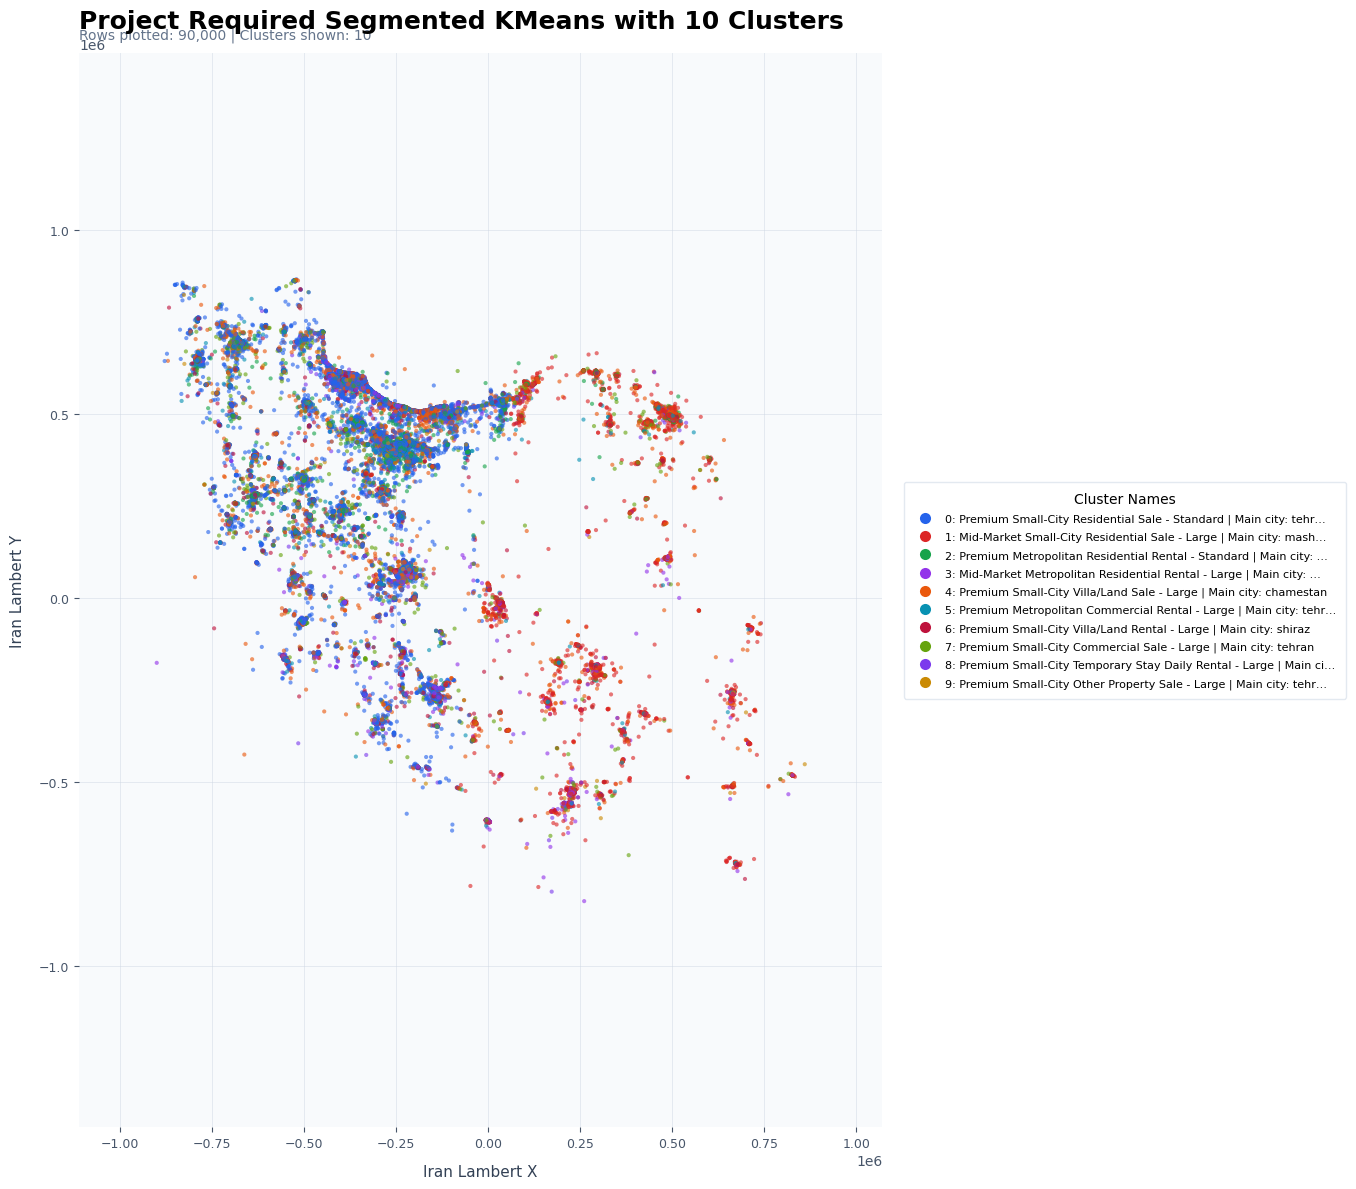

In [21]:
plot_clusters(
    model_data,
    "cluster_project_10",
    "Project Required Segmented KMeans with 10 Clusters"
)

In [22]:
k_sample = model_data.sample(n=min(MAX_K_SAMPLE_ROWS, len(model_data)), random_state=RANDOM_STATE).copy()
X_global = make_feature_matrix(k_sample, include_segment_identity=True)

global_k_results = []

for k in range(1, MAX_GLOBAL_K + 1):
    kmeans = KMeans(n_clusters=k, n_init=12, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_global)

    row = {
        "k": k,
        "wcss": kmeans.inertia_,
        "silhouette": np.nan,
        "min_cluster_share": np.nan
    }

    if k > 1:
        if len(k_sample) > MAX_SILHOUETTE_ROWS:
            idx = np.random.default_rng(RANDOM_STATE).choice(len(k_sample), size=MAX_SILHOUETTE_ROWS, replace=False)
            row["silhouette"] = silhouette_score(X_global[idx], labels[idx])
        else:
            row["silhouette"] = silhouette_score(X_global, labels)

        row["min_cluster_share"] = pd.Series(labels).value_counts(normalize=True).min()

    global_k_results.append(row)

global_k_evaluation = pd.DataFrame(global_k_results)

x = global_k_evaluation["k"].to_numpy(dtype=float)
y = global_k_evaluation["wcss"].to_numpy(dtype=float)

x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

start_x, start_y = x_norm[0], y_norm[0]
end_x, end_y = x_norm[-1], y_norm[-1]

distances = np.abs((end_x - start_x) * (start_y - y_norm) - (start_x - x_norm) * (end_y - start_y))
distances = distances / np.sqrt((end_x - start_x) ** 2 + (end_y - start_y) ** 2)

global_k_evaluation["elbow_distance"] = distances

silhouette_filled = global_k_evaluation["silhouette"].fillna(global_k_evaluation["silhouette"].min())
silhouette_norm = (silhouette_filled - silhouette_filled.min()) / (silhouette_filled.max() - silhouette_filled.min() + 1e-12)

elbow_norm = (global_k_evaluation["elbow_distance"] - global_k_evaluation["elbow_distance"].min()) / (
    global_k_evaluation["elbow_distance"].max() - global_k_evaluation["elbow_distance"].min() + 1e-12
)

balance_penalty = (0.02 - global_k_evaluation["min_cluster_share"].fillna(0)).clip(lower=0) * 8

global_k_evaluation["selection_score"] = 0.60 * elbow_norm + 0.40 * silhouette_norm - balance_penalty

macro_best_k = int(
    global_k_evaluation[global_k_evaluation["k"] > 1]
    .sort_values("selection_score", ascending=False)
    .iloc[0]["k"]
)

macro_best_k, global_k_evaluation

(2,
      k          wcss  silhouette  min_cluster_share  elbow_distance  selection_score
 0    1  2.297327e+06         NaN                NaN        0.000000        -0.160000
 1    2  1.246848e+06    0.563330            0.13581        0.338601         0.866620
 2    3  9.375931e+05    0.369156            0.11815        0.412023         0.745826
 3    4  7.682597e+05    0.375606            0.10440        0.435387         0.785398
 4    5  6.750959e+05    0.287177            0.08426        0.431501         0.678951
 5    6  5.962439e+05    0.289591            0.03669        0.422495         0.669300
 6    7  5.386849e+05    0.295931            0.03668        0.405871         0.653639
 7    8  5.012455e+05    0.297553            0.03665        0.382049         0.622664
 8    9  4.694842e+05    0.301088            0.03665        0.356196         0.591077
 9   10  4.453417e+05    0.304180            0.00941        0.327617         0.470508
 10  11  4.259844e+05    0.291972            0.025

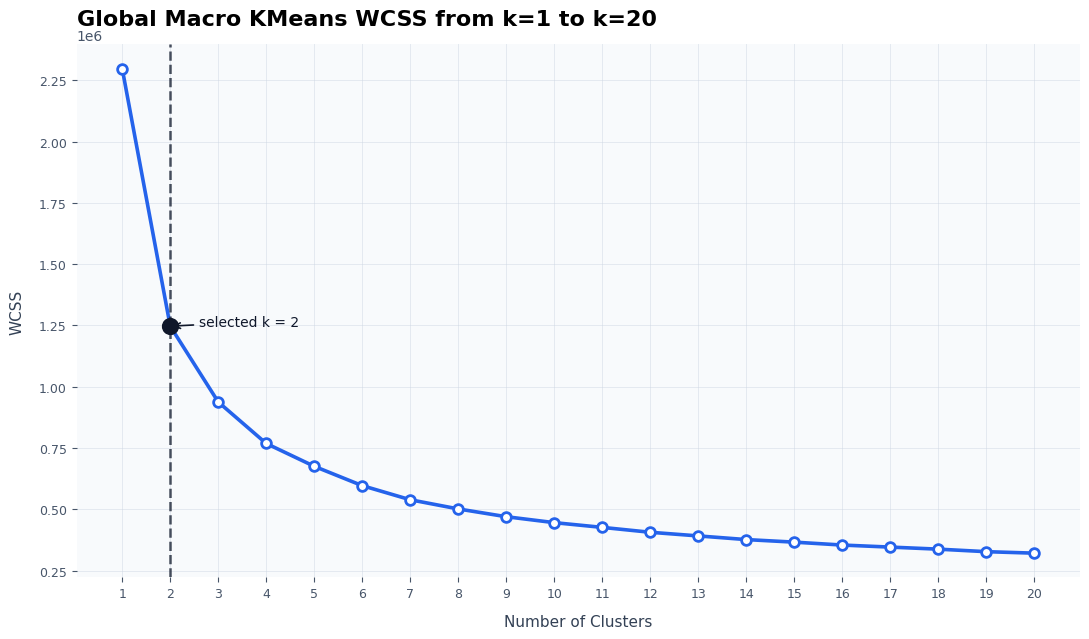

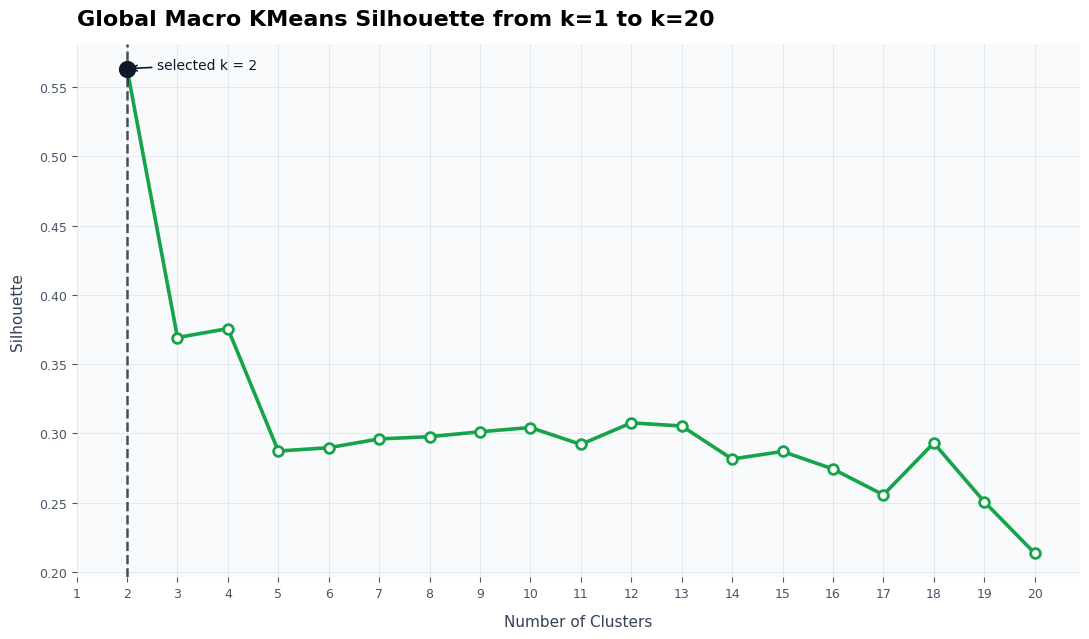

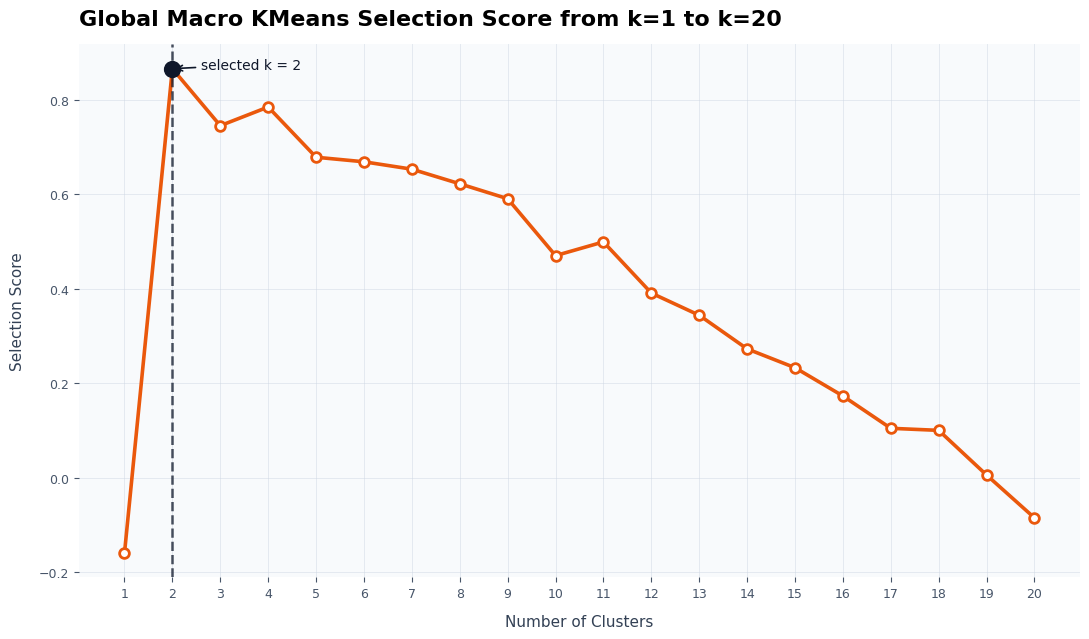

In [23]:
metric_plot_style = {
    "wcss": {
        "title": "Global Macro KMeans WCSS from k=1 to k=20",
        "ylabel": "WCSS",
        "color": "#2563EB"
    },
    "silhouette": {
        "title": "Global Macro KMeans Silhouette from k=1 to k=20",
        "ylabel": "Silhouette",
        "color": "#16A34A"
    },
    "selection_score": {
        "title": "Global Macro KMeans Selection Score from k=1 to k=20",
        "ylabel": "Selection Score",
        "color": "#EA580C"
    }
}

for metric, cfg in metric_plot_style.items():
    fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="white")

    ax.plot(
        global_k_evaluation["k"],
        global_k_evaluation[metric],
        marker="o",
        linewidth=2.6,
        markersize=7,
        color=cfg["color"],
        markerfacecolor="white",
        markeredgewidth=2
    )

    selected_value = global_k_evaluation.loc[global_k_evaluation["k"].eq(macro_best_k), metric].iloc[0]

    ax.axvline(
        macro_best_k,
        linestyle="--",
        linewidth=1.8,
        color="#0F172A",
        alpha=0.75
    )

    ax.scatter(
        [macro_best_k],
        [selected_value],
        s=130,
        color="#0F172A",
        zorder=5
    )

    ax.annotate(
        f"selected k = {macro_best_k}",
        xy=(macro_best_k, selected_value),
        xytext=(macro_best_k + 0.6, selected_value),
        fontsize=10,
        color="#0F172A",
        arrowprops=dict(arrowstyle="->", color="#0F172A", lw=1.2)
    )

    style_axis(ax)
    ax.set_title(cfg["title"], fontsize=16, fontweight="bold", loc="left", pad=14)
    ax.set_xlabel("Number of Clusters", fontsize=11, labelpad=10)
    ax.set_ylabel(cfg["ylabel"], fontsize=11, labelpad=10)
    ax.set_xticks(range(1, MAX_GLOBAL_K + 1))

    plt.tight_layout()
    plt.show()

In [24]:
def segment_min_k(n):
    if n >= 250000:
        return 4
    if n >= 100000:
        return 3
    if n >= 40000:
        return 2
    return 1

def segment_max_k(n):
    if n >= 250000:
        return 8
    if n >= 100000:
        return 6
    if n >= 40000:
        return 4
    if n >= 10000:
        return 3
    return 1

def choose_segment_k(segment_name, segment_data):
    n = len(segment_data)
    min_k = segment_min_k(n)
    max_k = min(segment_max_k(n), max(1, n - 1))

    if max_k <= 1:
        return {
            "model_segment": segment_name,
            "n_rows": n,
            "selected_k": 1,
            "best_metric_k": 1,
            "best_silhouette": np.nan,
            "best_elbow_k": 1
        }, pd.DataFrame([{
            "model_segment": segment_name,
            "k": 1,
            "wcss": 0,
            "silhouette": np.nan,
            "selection_score": 0
        }])

    sample = segment_data.sample(n=min(MAX_SEGMENT_K_SAMPLE_ROWS, n), random_state=RANDOM_STATE)
    X = make_feature_matrix(sample, include_segment_identity=False)

    rows = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        labels = kmeans.fit_predict(X)

        row = {
            "model_segment": segment_name,
            "k": k,
            "wcss": kmeans.inertia_,
            "silhouette": np.nan,
            "min_cluster_share": np.nan
        }

        if k > 1:
            if len(sample) > MAX_SILHOUETTE_ROWS:
                idx = np.random.default_rng(RANDOM_STATE).choice(len(sample), size=MAX_SILHOUETTE_ROWS, replace=False)
                row["silhouette"] = silhouette_score(X[idx], labels[idx])
            else:
                row["silhouette"] = silhouette_score(X, labels)

            row["min_cluster_share"] = pd.Series(labels).value_counts(normalize=True).min()

        rows.append(row)

    result = pd.DataFrame(rows)

    x = result["k"].to_numpy(dtype=float)
    y = result["wcss"].to_numpy(dtype=float)

    if len(x) > 1 and y.max() > y.min():
        x_norm = (x - x.min()) / (x.max() - x.min())
        y_norm = (y - y.min()) / (y.max() - y.min())
        start_x, start_y = x_norm[0], y_norm[0]
        end_x, end_y = x_norm[-1], y_norm[-1]
        distances = np.abs((end_x - start_x) * (start_y - y_norm) - (start_x - x_norm) * (end_y - start_y))
        distances = distances / np.sqrt((end_x - start_x) ** 2 + (end_y - start_y) ** 2)
    else:
        distances = np.zeros(len(result))

    result["elbow_distance"] = distances

    sil = result["silhouette"].fillna(result["silhouette"].min())
    sil_norm = (sil - sil.min()) / (sil.max() - sil.min() + 1e-12)

    elbow_norm = (result["elbow_distance"] - result["elbow_distance"].min()) / (
        result["elbow_distance"].max() - result["elbow_distance"].min() + 1e-12
    )

    balance_penalty = (0.03 - result["min_cluster_share"].fillna(0)).clip(lower=0) * 6
    complexity_penalty = result["k"] / max_k * 0.08

    result["selection_score"] = 0.55 * elbow_norm + 0.45 * sil_norm - balance_penalty - complexity_penalty

    candidate = result[result["k"] >= min_k].sort_values("selection_score", ascending=False).iloc[0]
    selected_k = int(candidate["k"])
    best_metric_k = int(result[result["k"] > 1].sort_values("selection_score", ascending=False).iloc[0]["k"])
    best_elbow_k = int(result.loc[result["elbow_distance"].idxmax(), "k"])
    best_silhouette = float(result["silhouette"].max()) if result["silhouette"].notna().any() else np.nan

    summary = {
        "model_segment": segment_name,
        "n_rows": n,
        "min_allowed_k": min_k,
        "max_allowed_k": max_k,
        "selected_k": selected_k,
        "best_metric_k": best_metric_k,
        "best_silhouette": best_silhouette,
        "best_elbow_k": best_elbow_k
    }

    return summary, result

segment_k_summaries = []
segment_k_details = []

for segment_name, segment_data in model_data.groupby("model_segment"):
    summary, details = choose_segment_k(segment_name, segment_data)
    segment_k_summaries.append(summary)
    segment_k_details.append(details)

segment_k_summary = pd.DataFrame(segment_k_summaries).sort_values("n_rows", ascending=False)
segment_k_evaluation = pd.concat(segment_k_details, ignore_index=True)

segment_k_summary

,model_segment,n_rows,min_allowed_k,max_allowed_k,selected_k,best_metric_k,best_silhouette,best_elbow_k
5,sale__residential,273348,4.0,8.0,4,2,0.553505,3
1,rent__residential,137390,3.0,6.0,3,3,0.660993,3
6,sale__villa_land,69794,2.0,4.0,2,2,0.637669,2
0,rent__commercial,48078,2.0,4.0,2,2,0.480675,2
2,rent__villa_land,36822,1.0,3.0,2,2,0.274701,2
3,sale__commercial,23944,1.0,3.0,2,2,0.377323,2
7,temporary_rent__temporary_stay,11697,1.0,3.0,2,2,0.642946,2
4,sale__other,8792,NaN,NaN,1,1,NaN,1


In [25]:
auto_segment_allocation = segment_k_summary.set_index("model_segment")["selected_k"].astype(int)

auto_segment_allocation.to_frame("auto_selected_k")

,auto_selected_k
model_segment,
sale__residential,4
rent__residential,3
sale__villa_land,2
rent__commercial,2
rent__villa_land,2
sale__commercial,2
temporary_rent__temporary_stay,2
sale__other,1


In [26]:
model_data = fit_segmented_clusters(
    model_data,
    auto_segment_allocation,
    "cluster_auto_segmented",
    "cluster_auto_segmented_label",
    RANDOM_STATE
)

model_data["cluster_auto_segmented"].value_counts().sort_index()

cluster_auto_segmented
0      46371
1     160431
2      26423
3      40123
4     104494
5      20078
6      12818
7       1928
8      67866
9      40256
10      7822
11     28247
12      8575
13     20492
14      3452
15     10560
16      1137
17      8792
Name: count, dtype: int64

In [27]:
cluster_auto_segmented_profile = cluster_profile_table(model_data, "cluster_auto_segmented")
model_data, cluster_auto_segmented_profile = add_cluster_names(model_data, cluster_auto_segmented_profile, "cluster_auto_segmented")

cluster_auto_segmented_profile

,count,transaction_type,property_group,model_segment,dominant_city,city_type,metropolitan_share,median_price,median_price_per_area,median_area,median_rooms,median_age,median_amenities,median_luxury_amenities,median_iran_x,median_iran_y,median_latitude,median_longitude,price_rank,size_rank,cluster_name
cluster_auto_segmented,,,,,,,,,,,,,,,,,,,,,
10,7822,rent,commercial,rent__commercial,mashhad,small_city,0.403571,12500000.0,220000.0,60.0,1.0,7.0,0.0,0.0,430500.786837,488663.249376,36.294399,58.792831,0.5,0.5,Mid-Market Small-City Commercial Rental - Stan...
9,40256,rent,commercial,rent__commercial,tehran,metropolitan,0.578318,18000000.0,302740.24024,67.0,1.0,8.0,0.0,0.0,-252298.335618,413980.934328,35.711664,51.214994,1.0,1.0,Premium Metropolitan Commercial Rental - Large...
6,12818,rent,residential,rent__residential,mashhad,metropolitan,0.779578,13000000.0,133333.333333,100.0,2.0,7.0,3.0,0.0,493869.115668,492244.769588,36.328979,59.506725,0.333333,0.666667,Affordable Metropolitan Residential Rental - S...
5,20078,rent,residential,rent__residential,isfahan,metropolitan,0.529418,15000000.0,150000.0,101.0,2.0,8.0,3.0,0.0,-164554.703532,-183105.349816,30.305678,52.329849,0.666667,1.0,Mid-Market Metropolitan Residential Rental - L...
4,104494,rent,residential,rent__residential,tehran,metropolitan,0.599624,17500000.0,200000.0,88.0,2.0,8.0,3.0,0.0,-244466.896566,416166.356937,35.733414,51.293289,1.0,0.333333,Premium Metropolitan Residential Rental - Comp...
12,8575,rent,villa_land,rent__villa_land,mashhad,small_city,0.235418,8000000.0,60000.0,150.0,2.0,11.0,2.0,0.0,296088.525758,-3835.750853,31.965071,57.102085,0.5,1.0,Mid-Market Small-City Villa/Land Rental - Larg...
11,28247,rent,villa_land,rent__villa_land,shiraz,small_city,0.386943,10100000.0,80500.0,135.0,2.0,13.0,2.0,0.0,-286679.677013,322900.240376,34.794598,50.864708,1.0,0.5,Premium Small-City Villa/Land Rental - Standar...
14,3452,sale,commercial,sale__commercial,mashhad,small_city,0.319270,2700000000.0,36363636.363636,75.0,1.0,7.0,0.0,0.0,332629.807145,482924.352726,36.253416,57.685545,0.5,1.0,Mid-Market Small-City Commercial Sale - Large ...
13,20492,sale,commercial,sale__commercial,tehran,small_city,0.489448,3800000000.0,59375000.0,71.0,1.0,9.0,0.0,0.0,-270371.689988,410944.800608,35.682905,51.012812,1.0,0.5,Premium Small-City Commercial Sale - Standard ...


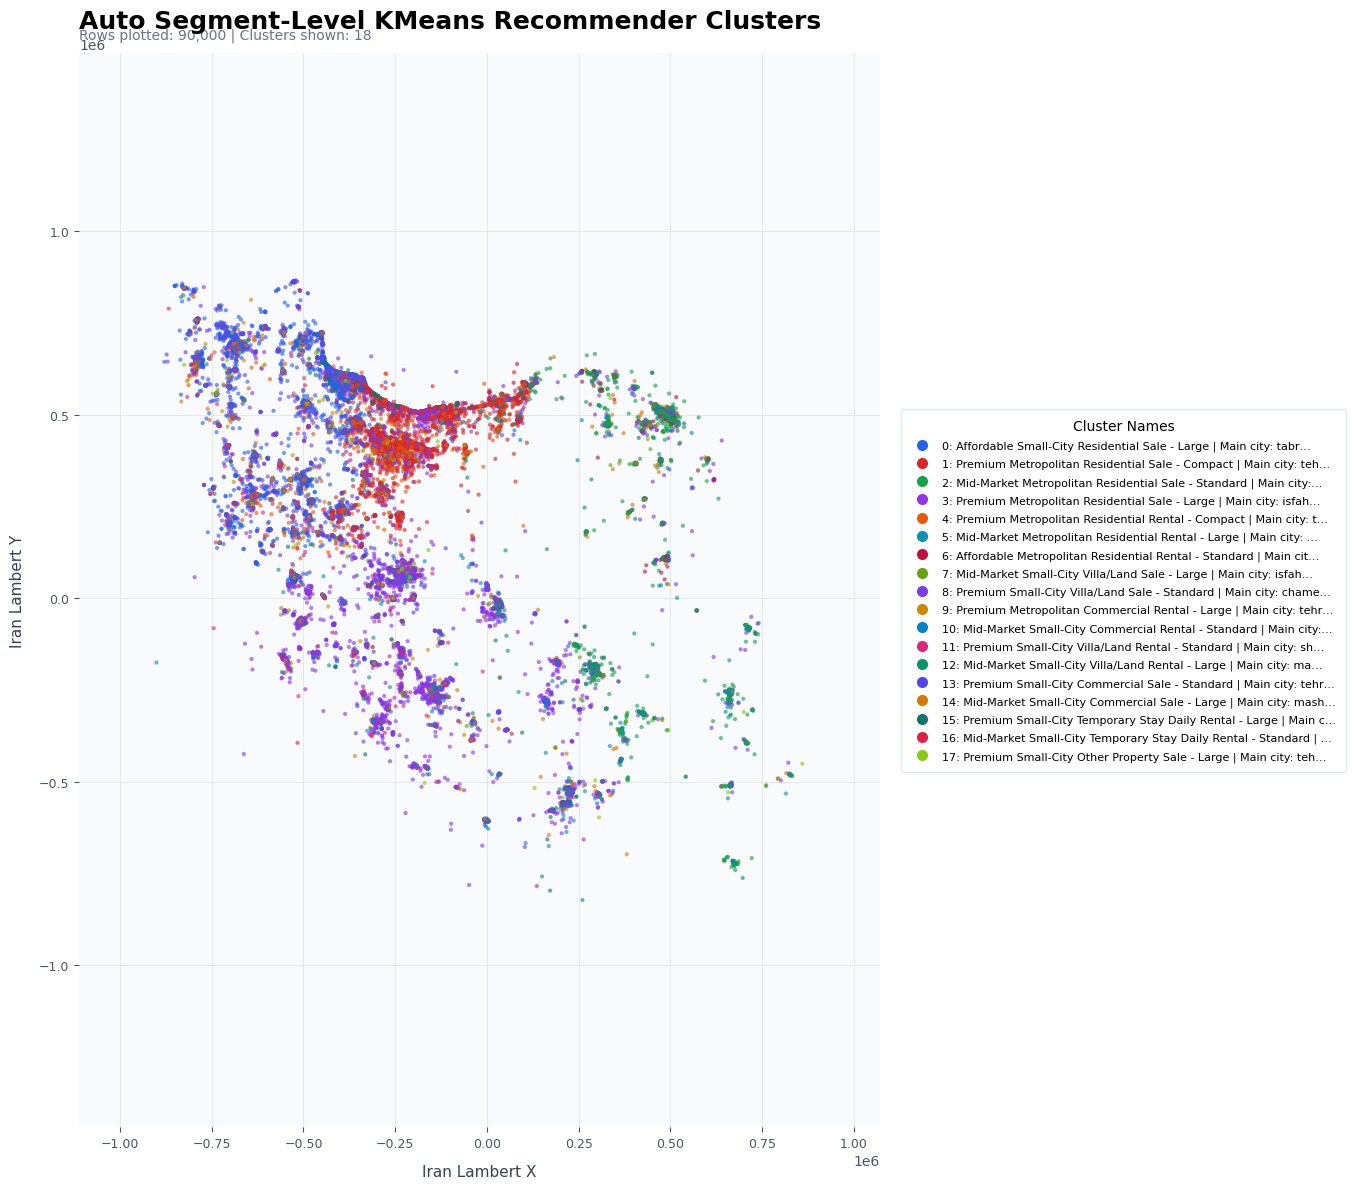

In [28]:
plot_clusters(
    model_data,
    "cluster_auto_segmented",
    "Auto Segment-Level KMeans Recommender Clusters"
)

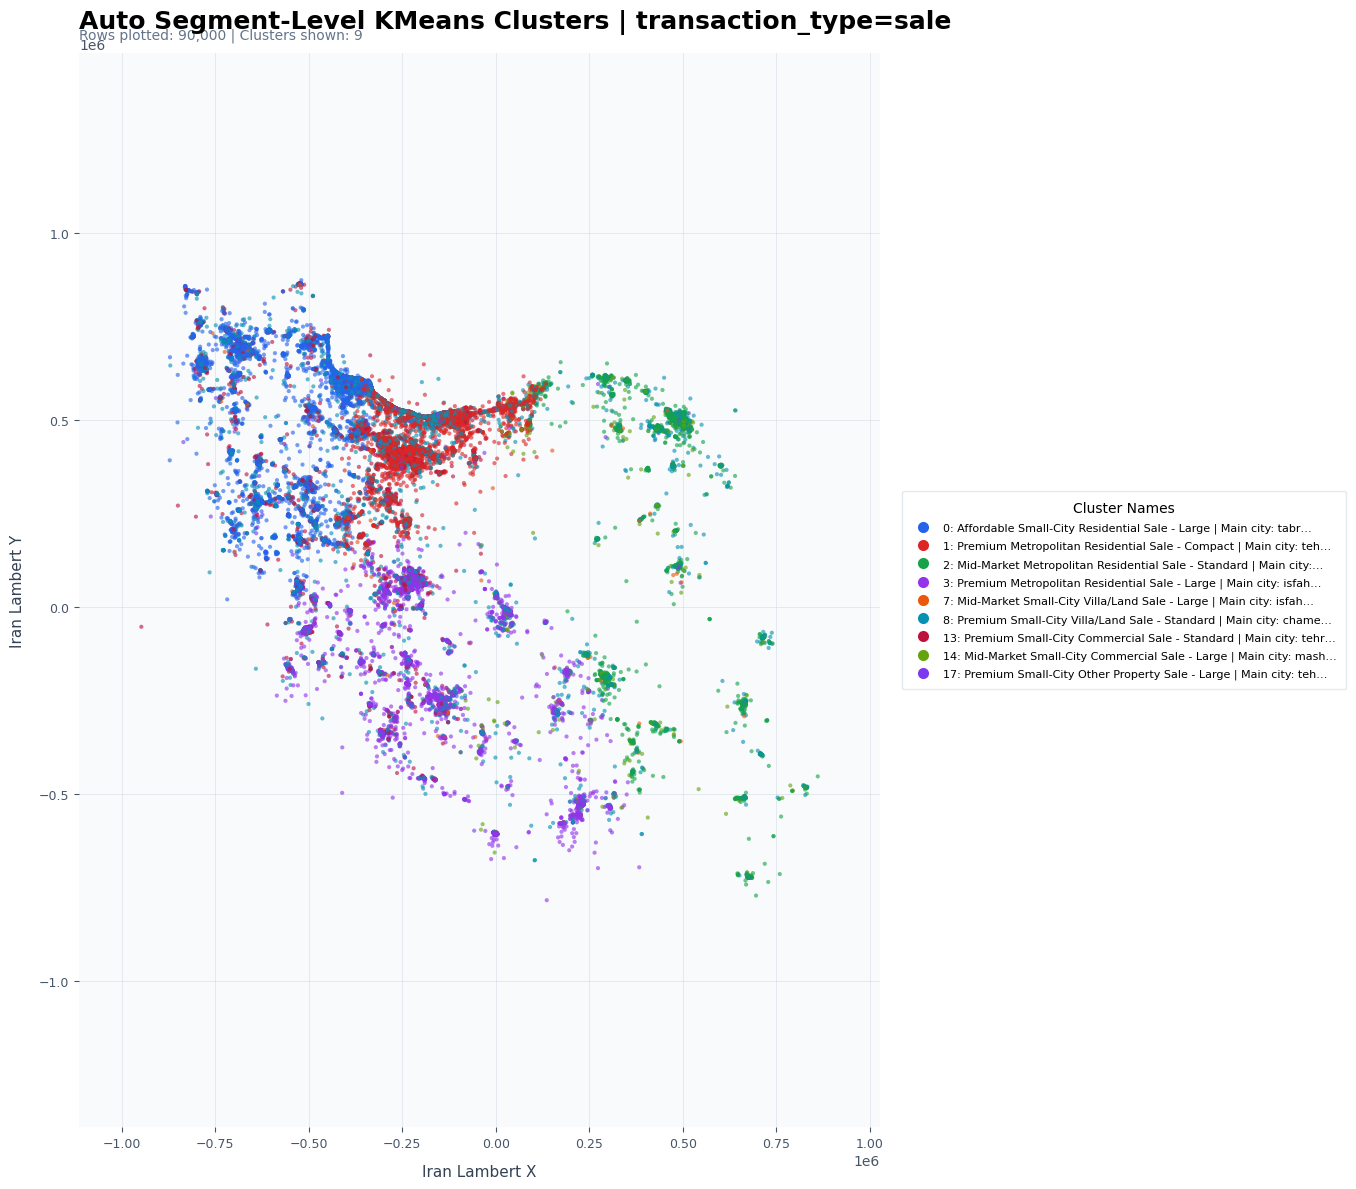

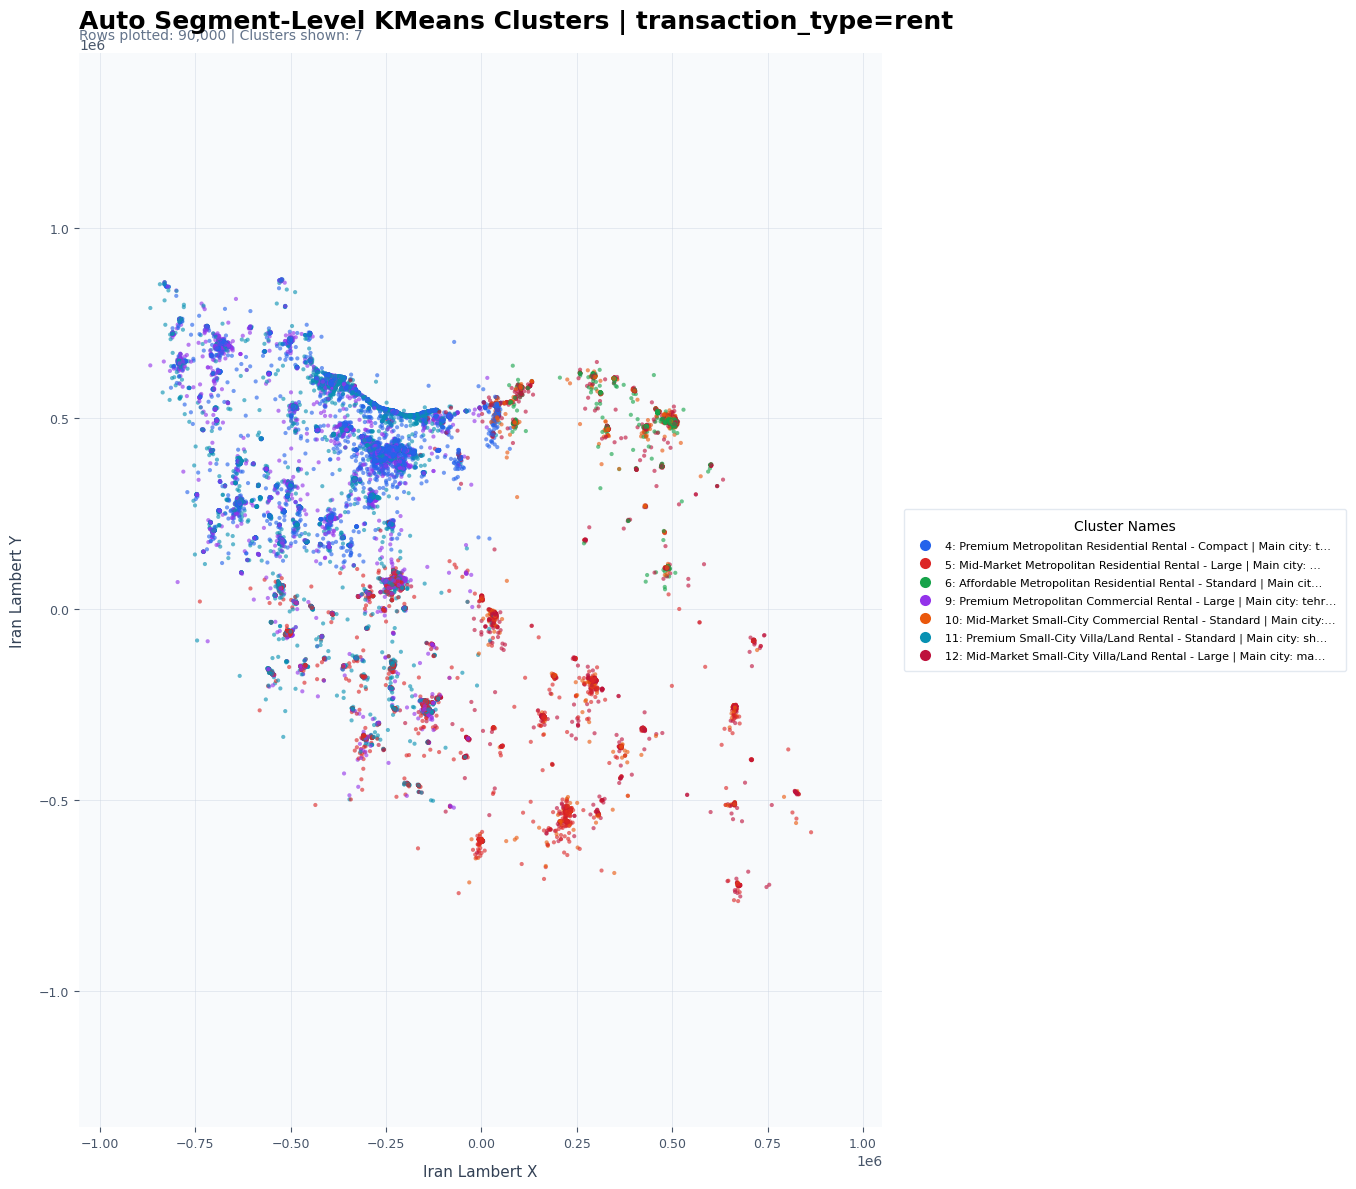

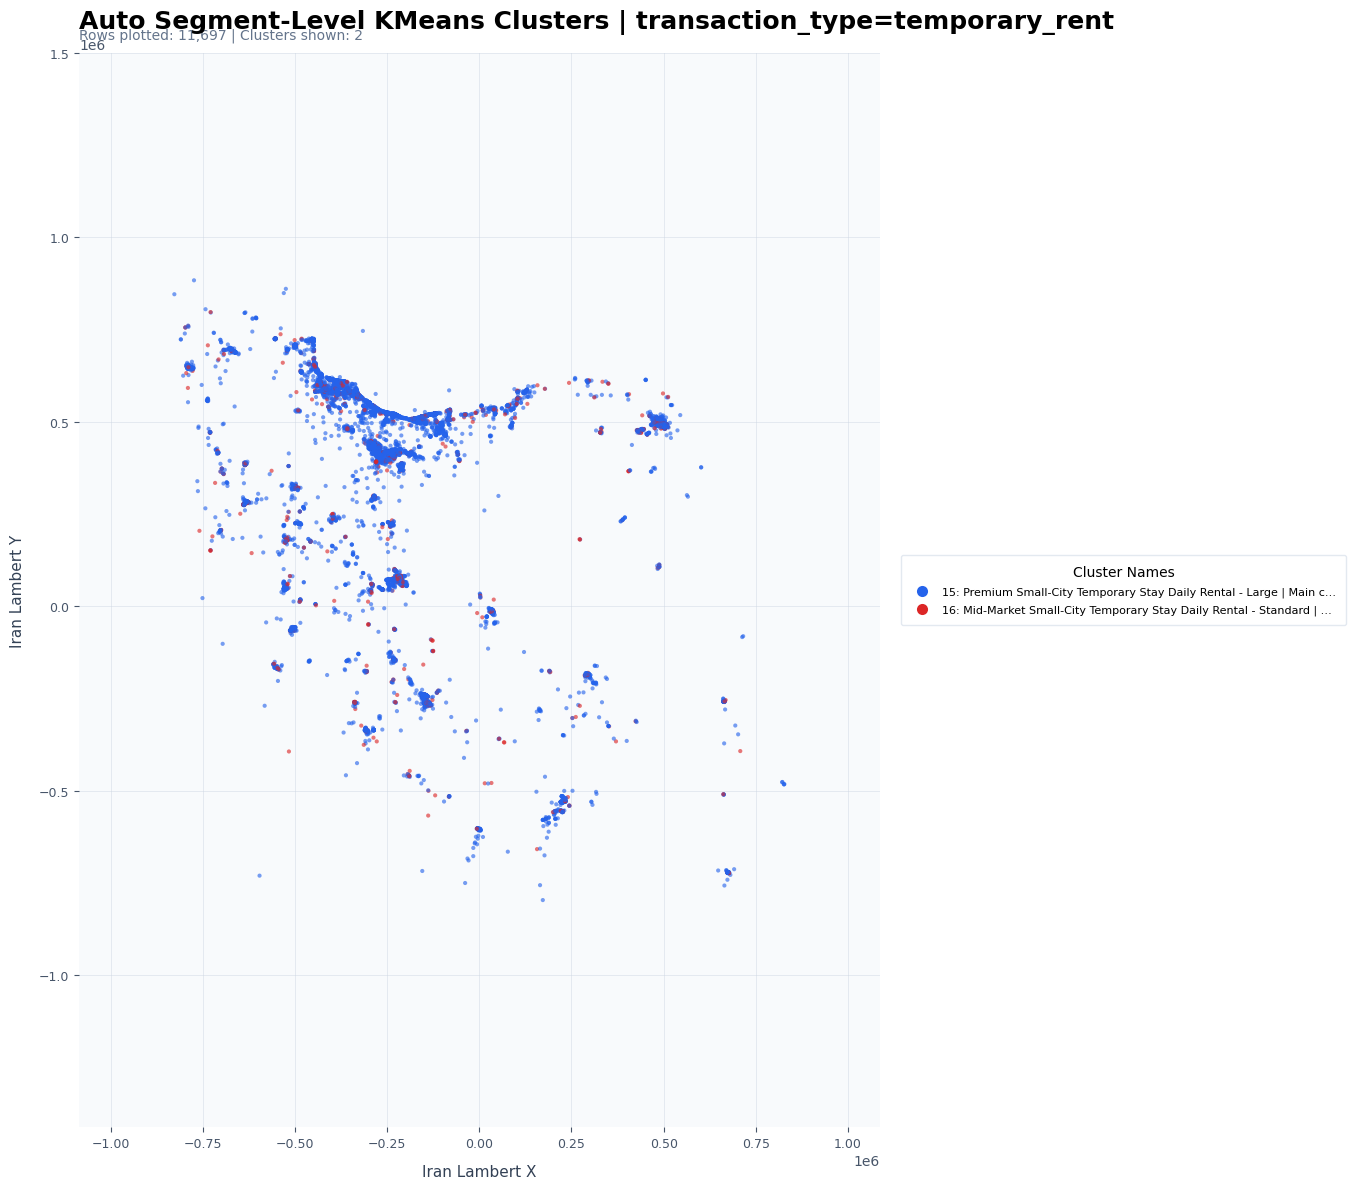

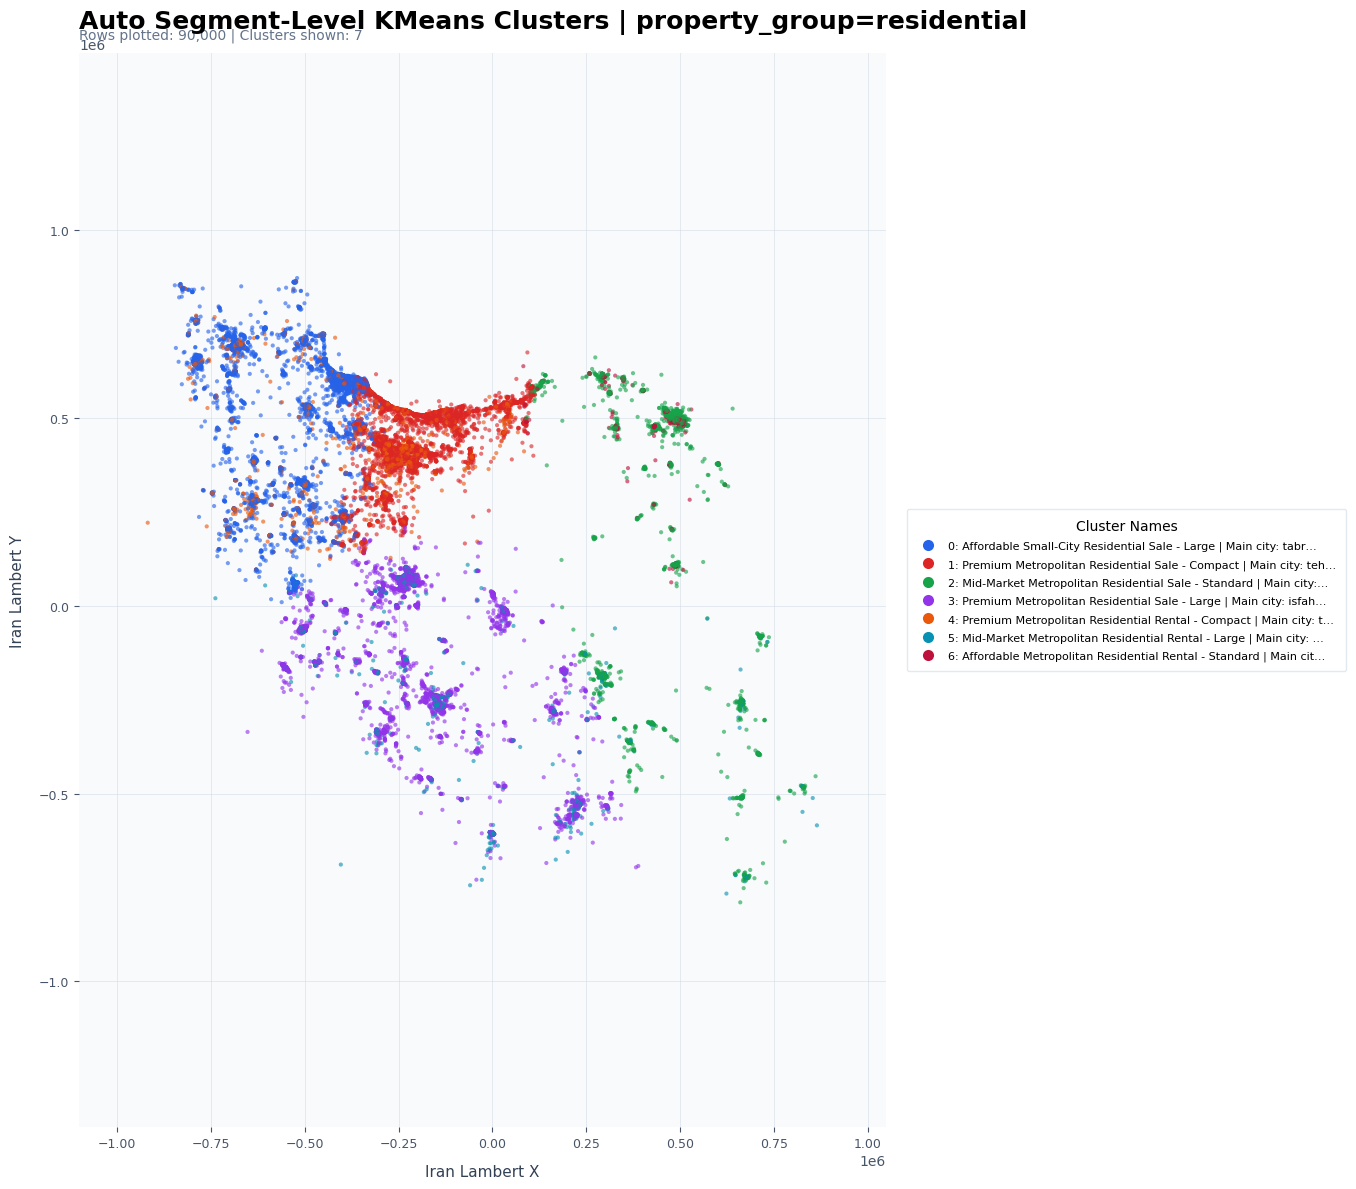

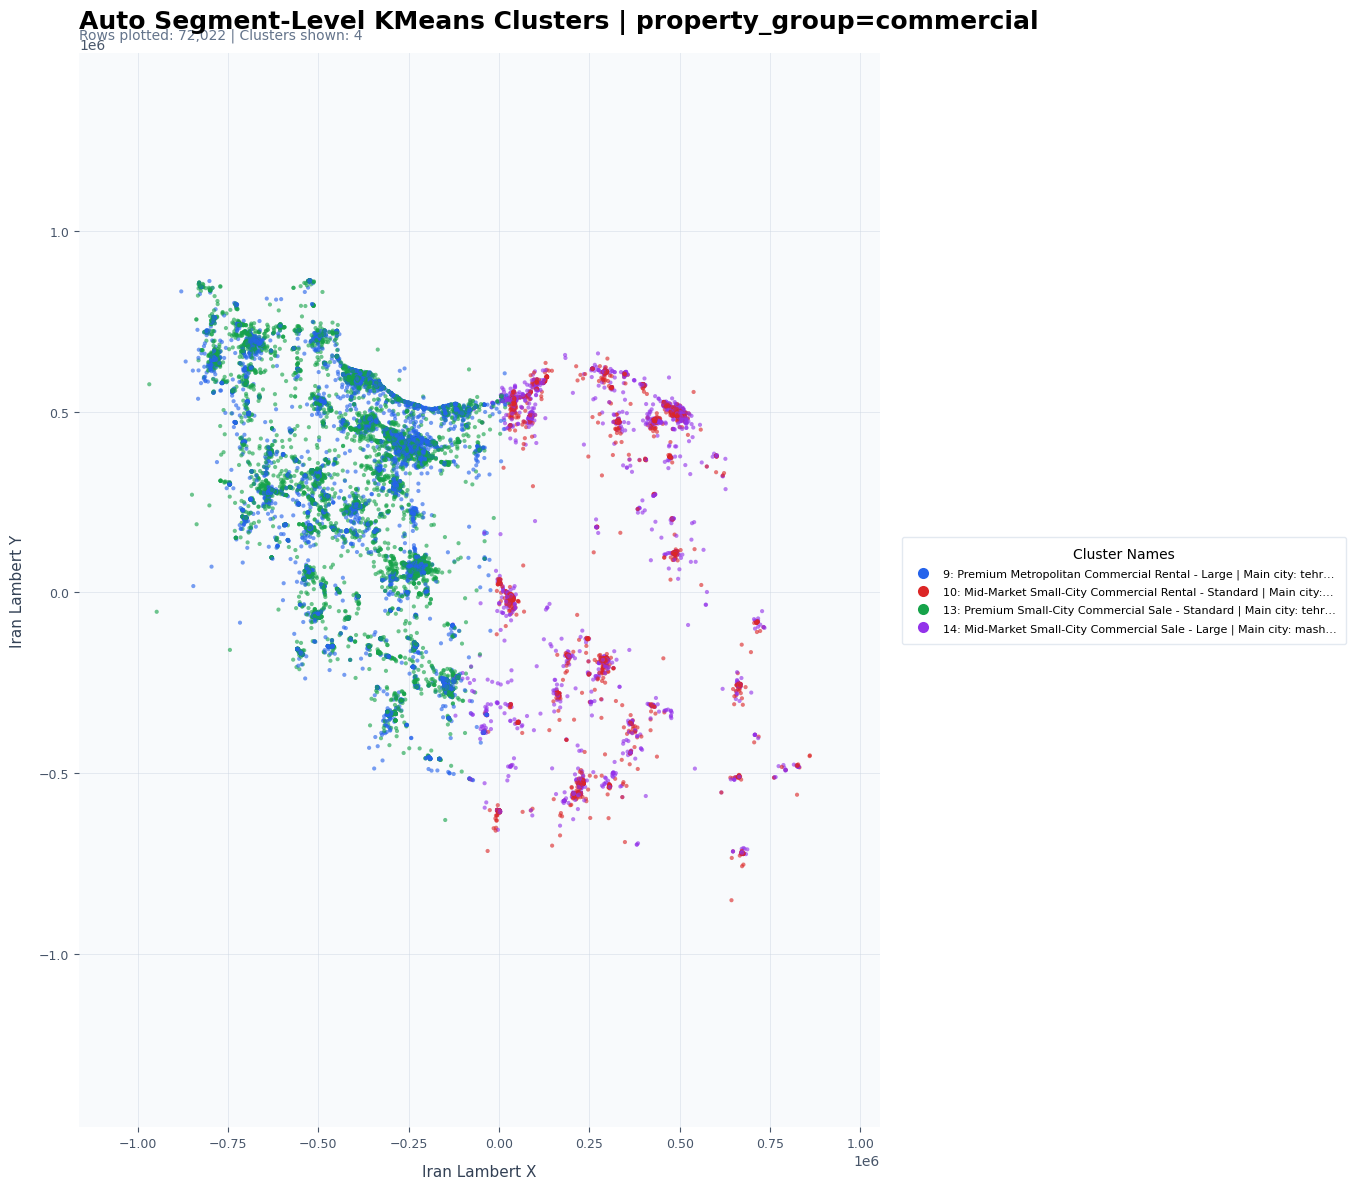

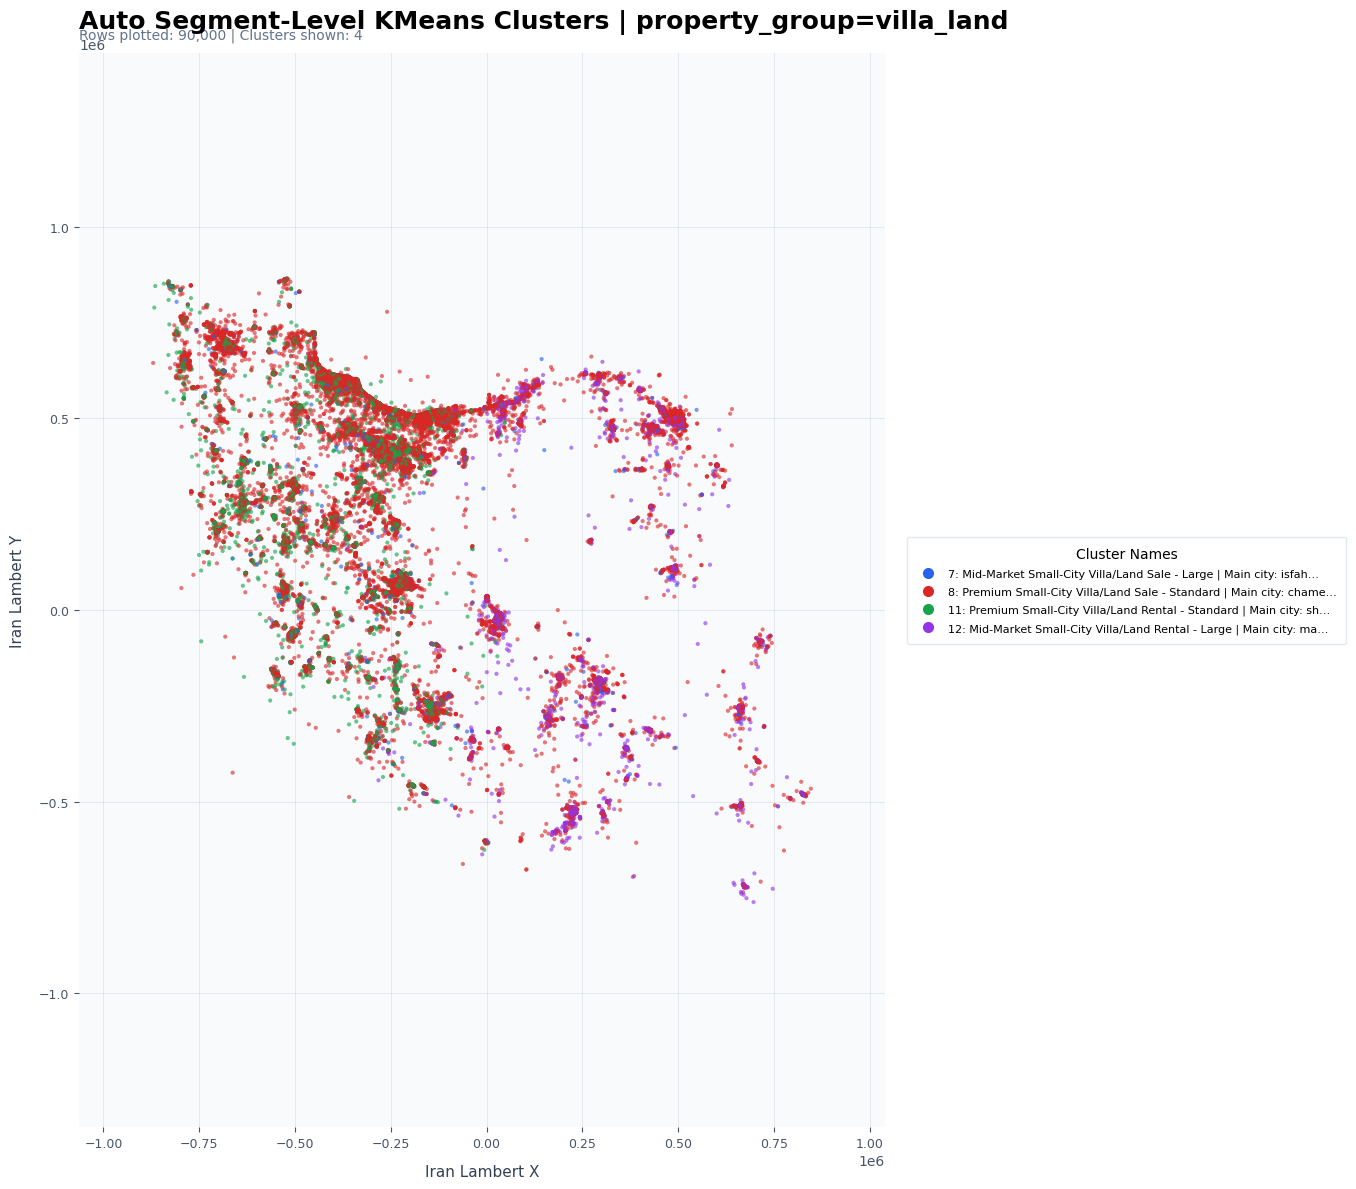

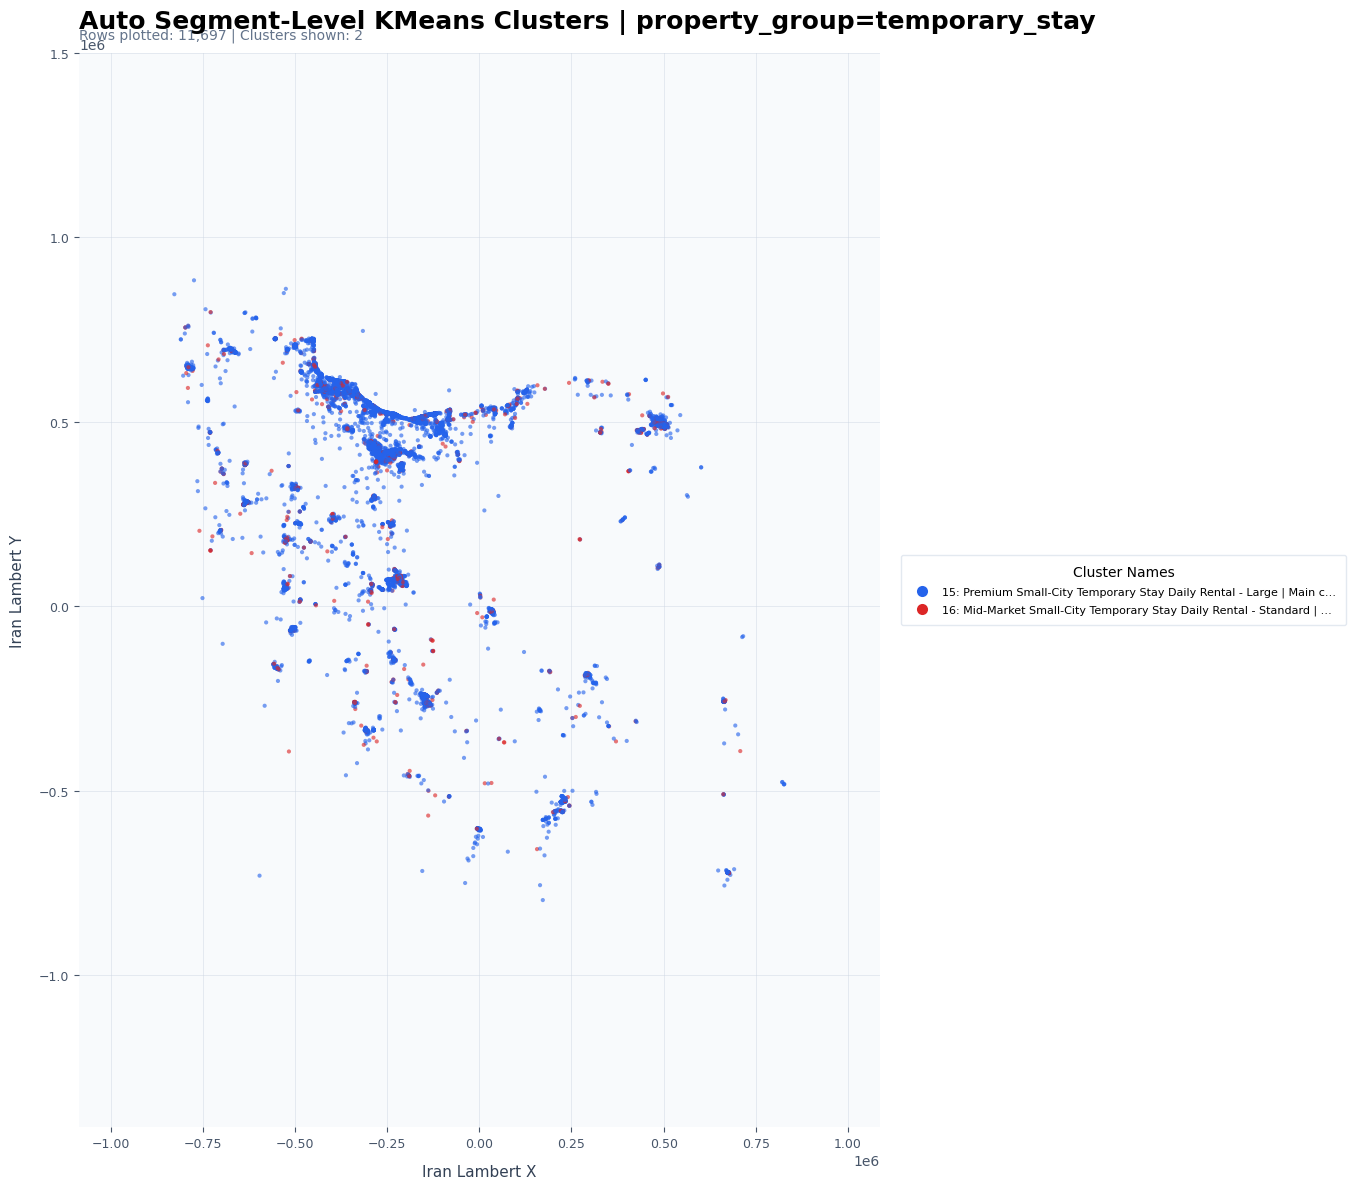

In [29]:
for transaction in ["sale", "rent", "temporary_rent"]:
    plot_clusters(
        model_data,
        "cluster_auto_segmented",
        f"Auto Segment-Level KMeans Clusters | transaction_type={transaction}",
        "transaction_type",
        transaction
    )

for property_group in ["residential", "commercial", "villa_land", "temporary_stay"]:
    plot_clusters(
        model_data,
        "cluster_auto_segmented",
        f"Auto Segment-Level KMeans Clusters | property_group={property_group}",
        "property_group",
        property_group
    )

In [30]:
def segmented_labels_for_seed(data, allocation, seed):
    labels_output = pd.Series(-1, index=data.index, dtype=int)
    cluster_offset = 0

    for segment_name, segment_k in allocation.items():
        mask = data["model_segment"].eq(segment_name)
        segment_data = data.loc[mask].copy()

        if len(segment_data) == 0:
            continue

        X = make_feature_matrix(segment_data, include_segment_identity=False)

        if int(segment_k) == 1 or X.shape[0] < int(segment_k):
            labels = np.zeros(X.shape[0], dtype=int)
        else:
            kmeans = KMeans(n_clusters=int(segment_k), n_init=10, random_state=seed)
            labels = kmeans.fit_predict(X)

        labels_output.loc[mask] = labels + cluster_offset
        cluster_offset += int(segment_k)

    return labels_output

stability_sample = model_data.sample(n=min(STABILITY_SAMPLE_ROWS, len(model_data)), random_state=RANDOM_STATE).copy()

stability_seeds = [7, 42, 99, 202]
stability_labels = {
    seed: segmented_labels_for_seed(stability_sample, auto_segment_allocation, seed)
    for seed in stability_seeds
}

stability_rows = []

for i, seed_a in enumerate(stability_seeds):
    for seed_b in stability_seeds[i + 1:]:
        stability_rows.append({
            "seed_a": seed_a,
            "seed_b": seed_b,
            "adjusted_rand_index": adjusted_rand_score(
                stability_labels[seed_a],
                stability_labels[seed_b]
            )
        })

stability_report = pd.DataFrame(stability_rows)

stability_report, stability_report["adjusted_rand_index"].mean()

(   seed_a  seed_b  adjusted_rand_index
 0       7      42             0.998137
 1       7      99             0.998372
 2       7     202             0.998112
 3      42      99             0.999764
 4      42     202             0.999972
 5      99     202             0.999736,
 np.float64(0.99901563985602))

In [31]:
cluster_auto_summary = cluster_auto_segmented_profile.reset_index()
cluster_auto_summary["cluster_meaning"] = cluster_auto_summary["cluster_name"]

cluster_project_10_summary = cluster_project_10_profile.reset_index()
cluster_project_10_summary["cluster_meaning"] = cluster_project_10_summary["cluster_name"]

cluster_project_10_summary, cluster_auto_summary

(   cluster_project_10   count transaction_type  property_group                   model_segment dominant_city     city_type  metropolitan_share  median_price  median_price_per_area  median_area  \
 0                   5   48078             rent      commercial                rent__commercial        tehran  metropolitan            0.549968    17400000.0           286111.10825         65.0   
 1                   3   20332             rent     residential               rent__residential       isfahan  metropolitan            0.522902    15000000.0          147959.183673        100.0   
 2                   2  117058             rent     residential               rent__residential        tehran  metropolitan            0.620669    16600000.0          188888.888889         90.0   
 3                   6   36822             rent      villa_land                rent__villa_land        shiraz    small_city            0.351757     9500000.0                75000.0        140.0   
 4             

In [32]:
output_columns = [
    column for column in [
        "cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug", "user_type",
        "transaction_type", "property_group", "model_segment",
        "city_type", "city_type_score", "city_type_missing",
        "segment_price", "segment_price_source", "price_per_area", "main_area",
        "rooms_count", "building_age", "floor_ratio", "amenity_count",
        "luxury_amenity_count", "essential_amenity_count", "utility_count",
        "city_price_level", "neighborhood_price_level",
        "latitude", "longitude", "utm_easting", "utm_northing", "iran_x", "iran_y",
        "cluster_project_10", "cluster_project_10_label",
        "cluster_project_10_name",
        "cluster_auto_segmented", "cluster_auto_segmented_label",
        "cluster_auto_segmented_name"
    ]
    if column in model_data.columns
]

model_data[output_columns].to_csv("/kaggle/working/real_estate_best_practice_clusters.csv", index=False)
cluster_project_10_profile.to_csv("/kaggle/working/cluster_project_10_profile.csv", index=True)
cluster_auto_segmented_profile.to_csv("/kaggle/working/cluster_auto_segmented_profile.csv", index=True)
global_k_evaluation.to_csv("/kaggle/working/global_macro_k_1_to_20_evaluation.csv", index=False)
segment_k_summary.to_csv("/kaggle/working/segment_k_summary.csv", index=False)
segment_k_evaluation.to_csv("/kaggle/working/segment_k_evaluation.csv", index=False)
stability_report.to_csv("/kaggle/working/stability_report.csv", index=False)
city_type_report.to_csv("/kaggle/working/city_type_report.csv", index=False)
city_type_counts.to_csv("/kaggle/working/city_type_counts.csv", index=True)

"/kaggle/working/real_estate_best_practice_clusters.csv",
"/kaggle/working/cluster_project_10_profile.csv",
"/kaggle/working/cluster_auto_segmented_profile.csv",
"/kaggle/working/global_macro_k_1_to_20_evaluation.csv",
"/kaggle/working/segment_k_summary.csv",
"/kaggle/working/segment_k_evaluation.csv",
"/kaggle/working/stability_report.csv",
"/kaggle/working/city_type_report.csv",
"/kaggle/working/city_type_counts.csv" 

'/kaggle/working/city_type_counts.csv'